In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'experiment_17.csv', 'train.csv', 'experiment_09.csv', '.ipynb_checkpoints', 'experiment_05.csv', 'experiment_02.csv', 'aggregated.csv', 'experiment_06.csv', 'experiment_15.csv', 'experiment_13.csv', 'experiment_11.csv', 'experiment_07.csv', 'experiment_10.csv', 'experiment_18.csv', 'experiment_03.csv', 'experiment_16.csv', 'experiment_01.csv', 'experiment_04.csv', 'experiment_14.csv', 'experiment_08.csv', 'experiment_12.csv', 'sample_data']


In [ ]:
import numpy as np
import pandas as pd

df_train = pd.read_csv('train.csv')
print(df_train.shape)
print(df_train.sample(10))

(18, 7)
    No material  feedrate  clamp_pressure tool_condition machining_finalized  \
4    5      wax        20           3.000         unworn                  no   
5    6      wax         6           4.000           worn                 yes   
3    4      wax         6           2.500         unworn                  no   
0    1      wax         6           4.000         unworn                 yes   
7    8      wax        20           4.000           worn                 yes   
14  15      wax         6           3.000           worn                 yes   
10  11      wax         3           4.000         unworn                 yes   
17  18      wax         3           2.500           worn                 yes   
15  16      wax        20           3.000           worn                  no   
16  17      wax         3           2.500         unworn                 yes   

   passed_visual_inspection  
4                       NaN  
5                        no  
3                    

In [ ]:
print(df_train['tool_condition'].unique())


['unworn' 'worn']


In [ ]:
# Description: Combine the train and experiment datasets into a single dataset

import numpy as np
import pandas as pd

# Load training dataset
df_train = pd.read_csv('train.csv')

# Dictionary to store experiment DataFrames
experiments = {}
total = 0

# Load experiment_01.csv to experiment_09.csv
for i in range(1, 10):
    filename = f'experiment_0{i}.csv'
    experiments[i] = pd.read_csv(filename)
    total += experiments[i].shape[0]
# experiments[i].shape[0] tell us number of rows in experiment 1

# Load experiment_10.csv to experiment_18.csv
for i in range(10, 19):
    filename = f'experiment_{i}.csv'
    experiments[i] = pd.read_csv(filename)
    total += experiments[i].shape[0]

print(f"Total rows across all experiments: {total}")

# Print shapes of all experiment datasets
for i in range(1, 19):
    print(f"df_{i} shape: {experiments[i].shape}")

########################
# Missing Value Handle #
########################

print("Missing values before handling:")
print(df_train.isnull().sum())
# .isnull().sum()) tell us hoe many null value in whole experiment


# Fill missing values
df_train['passed_visual_inspection'] = (
    df_train['passed_visual_inspection']
    .fillna('no')
)
print("\nMissing values after handling:")
print(df_train.isnull().sum())
# after write no to missing value check again missing values



##########################
# Combine all dataframes #
##########################

frames = []

for i in range(1, 19):

    df_exp = experiments[i].copy()

    # Add experiment information
    df_exp["exp_no"] = i
    df_exp["feedrate"] = float(df_train.loc[i - 1, "feedrate"])
    df_exp["clamp_pressure"] = df_train.loc[i - 1, "clamp_pressure"]

    # Add target label
    df_exp["target"] = (
        "worn"
        if df_train.loc[i - 1, "tool_condition"] == "worn"
        else "unworn"
    )

    frames.append(df_exp)

# Merge all experiments into one DataFrame
df = pd.concat(frames, axis=0, ignore_index=True)
#pd.concat()  Combines multiple DataFrames.

print("\nFirst 5 rows:")
print(df.head())

print("\nFinal Dataset Shape:")
print(df.shape)

################
# Save Dataset #
################

df.to_csv('aggregated.csv', index=False)

print("\nAggregated dataset saved successfully.")

Total rows across all experiments: 25286
df_1 shape: (1055, 48)
df_2 shape: (1668, 48)
df_3 shape: (1521, 48)
df_4 shape: (532, 48)
df_5 shape: (462, 48)
df_6 shape: (1296, 48)
df_7 shape: (565, 48)
df_8 shape: (605, 48)
df_9 shape: (740, 48)
df_10 shape: (1301, 48)
df_11 shape: (2314, 48)
df_12 shape: (2276, 48)
df_13 shape: (2233, 48)
df_14 shape: (2332, 48)
df_15 shape: (1381, 48)
df_16 shape: (602, 48)
df_17 shape: (2150, 48)
df_18 shape: (2253, 48)
Missing values before handling:
No                          0
material                    0
feedrate                    0
clamp_pressure              0
tool_condition              0
machining_finalized         0
passed_visual_inspection    4
dtype: int64

Missing values after handling:
No                          0
material                    0
feedrate                    0
clamp_pressure              0
tool_condition              0
machining_finalized         0
passed_visual_inspection    0
dtype: int64

First 5 rows:
   X1_ActualPosit

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the aggregated dataset
df = pd.read_csv("aggregated.csv")


# ==========================================================
# 1. BASIC INFORMATION ABOUT DATASET
# ==========================================================

#PRINT STARTING 5 ROWS
print(df.head())

#PRINT LAST 5 ROWS
print(df.tail())

#SHAPE (NO. OF ROWS, NO OF COLUMNS)
print(df.shape)

#NAME OF COLMNS
print(df.columns.tolist())

#DATATYPE
print(df.dtypes)

#INFORMATION
print(df.info())


   X1_ActualPosition  X1_ActualVelocity  X1_ActualAcceleration  \
0            198.000              0.000                  0.000   
1            198.000            -10.800               -350.000   
2            196.000            -17.800                 -6.250   
3            194.000            -18.000                  0.000   
4            193.000            -17.900                -18.800   

   X1_CommandPosition  X1_CommandVelocity  X1_CommandAcceleration  \
0             198.000               0.000                   0.000   
1             198.000             -13.600                -358.000   
2             196.000             -17.900                  -0.000   
3             194.000             -17.900                  -0.000   
4             192.000             -17.900                   0.000   

   X1_CurrentFeedback  X1_DCBusVoltage  X1_OutputCurrent  X1_OutputVoltage  \
0               0.180            0.021           329.000             2.770   
1             -10.900           

In [ ]:

# ==========================================================
# 2. CHECK MISSING VALUES
# ==========================================================


missing_values = df.isnull().sum()

#print columns along with there missing values
print(missing_values)

#total missing values
print(missing_values.sum())


X1_ActualPosition            0
X1_ActualVelocity            0
X1_ActualAcceleration        0
X1_CommandPosition           0
X1_CommandVelocity           0
X1_CommandAcceleration       0
X1_CurrentFeedback           0
X1_DCBusVoltage              0
X1_OutputCurrent             0
X1_OutputVoltage             0
X1_OutputPower               0
Y1_ActualPosition            0
Y1_ActualVelocity            0
Y1_ActualAcceleration        0
Y1_CommandPosition           0
Y1_CommandVelocity           0
Y1_CommandAcceleration       0
Y1_CurrentFeedback           0
Y1_DCBusVoltage              0
Y1_OutputCurrent             0
Y1_OutputVoltage             0
Y1_OutputPower               0
Z1_ActualPosition            0
Z1_ActualVelocity            0
Z1_ActualAcceleration        0
Z1_CommandPosition           0
Z1_CommandVelocity           0
Z1_CommandAcceleration       0
Z1_CurrentFeedback           0
Z1_DCBusVoltage              0
Z1_OutputCurrent             0
Z1_OutputVoltage             0
S1_Actua

In [ ]:

# ==========================================================
# 3. CHECK DUPLICATE ROWS
# ==========================================================

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 331



Target values:
target
worn      13308
unworn    11978
Name: count, dtype: int64

Target percentages:
target
worn     52.630
unworn   47.370
Name: proportion, dtype: float64


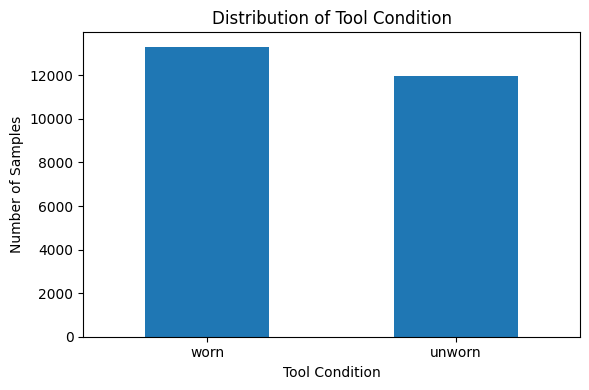

In [ ]:

# ==========================================================
# 4. TARGET VARIABLE ANALYSIS
# ==========================================================


#print target count like no of worn and unworn
print("\nTarget values:")
print(df["target"].value_counts())


# calculate percentage of target
print("\nTarget percentages:")
print(df["target"].value_counts(normalize=True) * 100)


# Plot target distribution

plt.figure(figsize=(6, 4))

df["target"].value_counts().plot(kind="bar")

plt.title("Distribution of Tool Condition")
plt.xlabel("Tool Condition")
plt.ylabel("Number of Samples")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:

# ==========================================================
# 5. EXPERIMENT ANALYSIS
# ==========================================================

print("\nNumber of samples in each experiment:")

#value_counts() counts how many times each unique value appears in a column
#and sort according to exp. number .
experiment_counts = df["exp_no"].value_counts().sort_index()
print(experiment_counts)


# Target associated with each experiment

print("\nTool condition for each experiment:")
# group of target value (worn/unworn ) and Take the first value from each group.
experiment_target = df.groupby("exp_no")["target"].first()

print(experiment_target)



Number of samples in each experiment:
exp_no
1     1055
2     1668
3     1521
4      532
5      462
6     1296
7      565
8      605
9      740
10    1301
11    2314
12    2276
13    2233
14    2332
15    1381
16     602
17    2150
18    2253
Name: count, dtype: int64

Tool condition for each experiment:
exp_no
1     unworn
2     unworn
3     unworn
4     unworn
5     unworn
6       worn
7       worn
8       worn
9       worn
10      worn
11    unworn
12    unworn
13      worn
14      worn
15      worn
16      worn
17    unworn
18      worn
Name: target, dtype: object


In [ ]:
# ==========================================================
# 6. STATISTICAL SUMMARY
# ==========================================================

print(df.describe())


       X1_ActualPosition  X1_ActualVelocity  X1_ActualAcceleration  \
count          25286.000          25286.000              25286.000   
mean             159.052             -0.289                  0.094   
std               19.331              5.658                 93.878   
min              141.000            -20.400              -1280.000   
25%              145.000             -2.050                -31.300   
50%              153.000              0.000                  0.000   
75%              162.000              0.200                 25.000   
max              198.000             50.700               1440.000   

       X1_CommandPosition  X1_CommandVelocity  X1_CommandAcceleration  \
count           25286.000           25286.000               25286.000   
mean              159.051              -0.283                   0.253   
std                19.331               5.664                  72.595   
min               141.000             -20.000               -1000.000   
25% 

In [ ]:

# ==========================================================
# 7. NUMERICAL COLUMNS
# ==========================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['X1_ActualPosition', 'X1_ActualVelocity', 'X1_ActualAcceleration', 'X1_CommandPosition', 'X1_CommandVelocity', 'X1_CommandAcceleration', 'X1_CurrentFeedback', 'X1_DCBusVoltage', 'X1_OutputCurrent', 'X1_OutputVoltage', 'X1_OutputPower', 'Y1_ActualPosition', 'Y1_ActualVelocity', 'Y1_ActualAcceleration', 'Y1_CommandPosition', 'Y1_CommandVelocity', 'Y1_CommandAcceleration', 'Y1_CurrentFeedback', 'Y1_DCBusVoltage', 'Y1_OutputCurrent', 'Y1_OutputVoltage', 'Y1_OutputPower', 'Z1_ActualPosition', 'Z1_ActualVelocity', 'Z1_ActualAcceleration', 'Z1_CommandPosition', 'Z1_CommandVelocity', 'Z1_CommandAcceleration', 'Z1_CurrentFeedback', 'Z1_DCBusVoltage', 'Z1_OutputCurrent', 'Z1_OutputVoltage', 'S1_ActualPosition', 'S1_ActualVelocity', 'S1_ActualAcceleration', 'S1_CommandPosition', 'S1_CommandVelocity', 'S1_CommandAcceleration', 'S1_CurrentFeedback', 'S1_DCBusVoltage', 'S1_OutputCurrent', 'S1_OutputVoltage', 'S1_OutputPower', 'S1_SystemInertia', 'M1_CURRENT_PROGRAM_NUMBER', 'M1_s

In [ ]:

# ==========================================================
# 8. CATEGORICAL COLUMNS
# ==========================================================

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)



Categorical columns:
['Machining_Process', 'target']


In [ ]:
# ==========================================================
# 9. UNIQUE VALUES
# ==========================================================

for column in df.columns:

    print("\nColumn:", column)

    print("Number of unique values:",
          df[column].nunique())


Column: X1_ActualPosition
Number of unique values: 58

Column: X1_ActualVelocity
Number of unique values: 830

Column: X1_ActualAcceleration
Number of unique values: 259

Column: X1_CommandPosition
Number of unique values: 58

Column: X1_CommandVelocity
Number of unique values: 1739

Column: X1_CommandAcceleration
Number of unique values: 2296

Column: X1_CurrentFeedback
Number of unique values: 2386

Column: X1_DCBusVoltage
Number of unique values: 1042

Column: X1_OutputCurrent
Number of unique values: 12

Column: X1_OutputVoltage
Number of unique values: 1831

Column: X1_OutputPower
Number of unique values: 4835

Column: Y1_ActualPosition
Number of unique values: 335

Column: Y1_ActualVelocity
Number of unique values: 859

Column: Y1_ActualAcceleration
Number of unique values: 264

Column: Y1_CommandPosition
Number of unique values: 335

Column: Y1_CommandVelocity
Number of unique values: 1786

Column: Y1_CommandAcceleration
Number of unique values: 2245

Column: Y1_CurrentFeedback

In [ ]:

# ==========================================================
# 10. ANALYZE FEEDRATE
# ==========================================================

print("\nFeedrate statistics:")
print(df["feedrate"].describe())

print("\nFeedrate by target:")
print(
    df.groupby("target")["feedrate"].describe()
)


Feedrate statistics:
count   25286.000
mean        7.124
std         6.167
min         3.000
25%         3.000
50%         3.000
75%         6.000
max        20.000
Name: feedrate, dtype: float64

Feedrate by target:
           count  mean   std   min   25%   50%    75%    max
target                                                      
unworn 11978.000 6.801 6.267 3.000 3.000 3.000  6.000 20.000
worn   13308.000 7.414 6.061 3.000 3.000 3.000 12.000 20.000


In [ ]:

# ==========================================================
# 11. ANALYZE CLAMP PRESSURE
# ==========================================================

print("\nClamp pressure statistics:")
print(df["clamp_pressure"].describe())

print("\nClamp pressure by target:")
print(
    df.groupby("target")["clamp_pressure"].describe()
)



Clamp pressure statistics:
count   25286.000
mean        3.368
std         0.616
min         2.500
25%         3.000
50%         3.000
75%         4.000
max         4.000
Name: clamp_pressure, dtype: float64

Clamp pressure by target:
           count  mean   std   min   25%   50%   75%   max
target                                                    
unworn 11978.000 3.309 0.618 2.500 3.000 3.000 4.000 4.000
worn   13308.000 3.422 0.609 2.500 3.000 4.000 4.000 4.000


In [ ]:
# Features: 52
# Observations: 25286

#############
### Notes Based on (9. Unique Values) ###
#############

### 1. The dataset is combined.csv from train and experiment datasets
### 2. Convert TARGET to binary (0,1) --> 0: Unworn, 1: Worn
### 3. Drop list:
# 'MACHINING_PROCESS' -->  Not sure what it is and how it is related to the target
# 'Z1_CURRENTFEEDBACK', --> All same - 0.0
# 'Z1_DCBUSVOLTAGE', --> All same - 0.0
# 'Z1_OUTPUTCURRENT', --> All same - 0.0
# 'Z1_OUTPUTVOLTAGE', --> All same - 0.0
# 'S1_COMMANDACCELERATION' --> Actual value is 'S1_ACTUALPOSITION' is there, no need to command
# 'S1_SYSTEMINERTIA' --> All same - 12.0
# 'M1_CURRENT_PROGRAM_NUMBER' --> There is miss leading information all should be 1
# 'M1_SEQUENCE_NUMBER' --> There is miss leading information all should be 1
# 'M1_CURRENT_FEEDRATE' --> There is miss leading information, correct one is 'FEEDRATE'
# 'EXP_NO' --> Experiment number is not needed, it is cardinal variable

### 4. List should convert to numeric:
# 'FEEDRATE'
# 'CLAMP_PRESSURE'

In [ ]:
# Notes Implementation
df.columns = df.columns.str.upper()

df = df.drop("EXP_NO", axis=1) # Drop EXP_NO column


df["TARGET"] = df["TARGET"].apply(lambda x: 1 if x == "worn" else 0) # Convert to binary

"""
###drop_list = ['MACHINING_PROCESS', 'Z1_CURRENTFEEDBACK', 'Z1_DCBUSVOLTAGE',
             'Z1_OUTPUTCURRENT', 'Z1_OUTPUTVOLTAGE', 'S1_COMMANDACCELERATION',
             'S1_SYSTEMINERTIA', 'M1_CURRENT_PROGRAM_NUMBER', 'M1_SEQUENCE_NUMBER',
             'M1_CURRENT_FEEDRATE', "EXP_NO", "Z1_COMMANDVELOCITY", "Z1_COMMANDACCELERATION"]"

###df.drop(drop_list, axis=1, inplace=True)"""

cat_to_numeric = ['FEEDRATE', 'CLAMP_PRESSURE',
                  'Z1_COMMANDVELOCITY', 'Z1_COMMANDACCELERATION',
                  'Z1_CURRENTFEEDBACK', 'Z1_DCBUSVOLTAGE',
                  'Z1_OUTPUTCURRENT', 'Z1_OUTPUTVOLTAGE', 'S1_COMMANDACCELERATION',
                  'S1_SYSTEMINERTIA','M1_CURRENT_FEEDRATE'] # Convert to numeric


In [ ]:
##########################
#EDA
########

In [ ]:
# 1. General Picture of the Dataset
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.select_dtypes(include=np.number).quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

check_df(df)

##################### Shape #####################
(25286, 51)
##################### Types #####################
X1_ACTUALPOSITION            float64
X1_ACTUALVELOCITY            float64
X1_ACTUALACCELERATION        float64
X1_COMMANDPOSITION           float64
X1_COMMANDVELOCITY           float64
X1_COMMANDACCELERATION       float64
X1_CURRENTFEEDBACK           float64
X1_DCBUSVOLTAGE              float64
X1_OUTPUTCURRENT             float64
X1_OUTPUTVOLTAGE             float64
X1_OUTPUTPOWER               float64
Y1_ACTUALPOSITION            float64
Y1_ACTUALVELOCITY            float64
Y1_ACTUALACCELERATION        float64
Y1_COMMANDPOSITION           float64
Y1_COMMANDVELOCITY           float64
Y1_COMMANDACCELERATION       float64
Y1_CURRENTFEEDBACK           float64
Y1_DCBUSVOLTAGE              float64
Y1_OUTPUTCURRENT             float64
Y1_OUTPUTVOLTAGE             float64
Y1_OUTPUTPOWER               float64
Z1_ACTUALPOSITION            float64
Z1_ACTUALVELOCITY            float64


In [ ]:
# Catch Numeric and Categorical Value


def grap_column_names(dataframe, categorical_th=10, cardinal_th=20):
    """
    It gives the names of categorical, numerical and categorical but cardinal variables in the data set.
    Note: Categorical variables with numerical appearance are also included."""

    """
    Cardinal Variables: Variables that are categorical and do not carry information,
    that is, have too many classes, are called variables with high cardinality.
    """

    """
    Returns
    ------
        categorical_cols: list
                Categorical variable list
        num_cols: list
                Numeric variable list
        categorical_but_cardinal: list
                Categorical variables with high cardinality list
    """
    # categorical_cols, categorical_but_cardinal
    categorical_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    numeric_but_categorical = [col for col in dataframe.columns if dataframe[col].nunique() < categorical_th and
                   dataframe[col].dtypes != "O"]
    categorical_but_cardinal = [col for col in dataframe.columns if dataframe[col].nunique() > cardinal_th and
                   dataframe[col].dtypes == "O"]
    categorical_cols = categorical_cols + numeric_but_categorical
    categorical_cols = [col for col in categorical_cols if col not in categorical_but_cardinal]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in numeric_but_categorical]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'categorical_cols: {len(categorical_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'categorical_but_cardinal: {len(categorical_but_cardinal)}')
    print(f'numeric_but_categorical: {len(numeric_but_categorical)}')

    return categorical_cols, num_cols, categorical_but_cardinal

cat_cols, num_cols, cat_but_car = grap_column_names(df)

print("\n\nCategorical Columns: \n", cat_cols)
print("\n\nNumeric Columns: \n", num_cols)
[print("\n\nCategorical but Cardinal EMPTY!!!\n") if cat_but_car == [] else print("Categorical but Cardinal: \n", cat_but_car)]
print("#"*50)


Observations: 25286
Variables: 51
categorical_cols: 12
num_cols: 39
categorical_but_cardinal: 0
numeric_but_categorical: 11


Categorical Columns: 
 ['MACHINING_PROCESS', 'Z1_CURRENTFEEDBACK', 'Z1_DCBUSVOLTAGE', 'Z1_OUTPUTCURRENT', 'Z1_OUTPUTVOLTAGE', 'S1_COMMANDACCELERATION', 'S1_SYSTEMINERTIA', 'M1_CURRENT_PROGRAM_NUMBER', 'M1_CURRENT_FEEDRATE', 'FEEDRATE', 'CLAMP_PRESSURE', 'TARGET']


Numeric Columns: 
 ['X1_ACTUALPOSITION', 'X1_ACTUALVELOCITY', 'X1_ACTUALACCELERATION', 'X1_COMMANDPOSITION', 'X1_COMMANDVELOCITY', 'X1_COMMANDACCELERATION', 'X1_CURRENTFEEDBACK', 'X1_DCBUSVOLTAGE', 'X1_OUTPUTCURRENT', 'X1_OUTPUTVOLTAGE', 'X1_OUTPUTPOWER', 'Y1_ACTUALPOSITION', 'Y1_ACTUALVELOCITY', 'Y1_ACTUALACCELERATION', 'Y1_COMMANDPOSITION', 'Y1_COMMANDVELOCITY', 'Y1_COMMANDACCELERATION', 'Y1_CURRENTFEEDBACK', 'Y1_DCBUSVOLTAGE', 'Y1_OUTPUTCURRENT', 'Y1_OUTPUTVOLTAGE', 'Y1_OUTPUTPOWER', 'Z1_ACTUALPOSITION', 'Z1_ACTUALVELOCITY', 'Z1_ACTUALACCELERATION', 'Z1_COMMANDPOSITION', 'Z1_COMMANDVELOCITY', 'Z1_C

In [ ]:
# Categorical Variables Analysis

def cat_summary(dataframe, col_name, plot=False):
    """
    This function shows the frequency of categorical variables.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    col_name : str
        The name of the column to be analyzed.
    plot : bool, optional
        The default is False.
    Returns
    -------
    None.
    """
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show()

for col in cat_cols:
    cat_summary(df,col)
print("#"*50)
# Drop cols should be Numeric
cat_cols = [col for col in cat_cols if col not in cat_to_numeric]

print(cat_cols)


                   MACHINING_PROCESS  Ratio
MACHINING_PROCESS                          
Layer 1 Up                      4085 16.155
Repositioning                   3377 13.355
Layer 2 Up                      3104 12.276
Layer 3 Up                      2794 11.050
Layer 1 Down                    2655 10.500
End                             2585 10.223
Layer 2 Down                    2528  9.998
Layer 3 Down                    2354  9.309
Prep                            1795  7.099
end                                8  0.032
Starting                           1  0.004
##########################################
                    Z1_CURRENTFEEDBACK   Ratio
Z1_CURRENTFEEDBACK                            
0.000                            25286 100.000
##########################################
                 Z1_DCBUSVOLTAGE   Ratio
Z1_DCBUSVOLTAGE                         
0.000                      25286 100.000
##########################################
                  Z1_OUTPUTCURRENT 

In [ ]:
# Numeric Variables Analysis

for col in cat_to_numeric:
    num_cols.append(col)

def numerical_col_summary(dataframe, col_name, plot=False):

    """
    This function shows the frequency of numerical variables.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    col_name : str
        The name of the column to be analyzed.
    plot : bool, optional
        The default is False.
    Returns
    -------
    None.
    """
    print(dataframe[col_name].describe([0.01, 0.05, 0.75, 0.90, 0.99]).T)
    print("##########################################")
    if plot:
        sns.histplot(dataframe[col_name], kde=True)
        plt.xlabel(col_name)
        plt.title(f"{col_name} Distribution")
        plt.show()

for col in num_cols:
    numerical_col_summary(df,col)
print("#"*50)


count   25286.000
mean      159.052
std        19.331
min       141.000
1%        141.000
5%        141.000
50%       153.000
75%       162.000
90%       198.000
99%       198.000
max       198.000
Name: X1_ACTUALPOSITION, dtype: float64
##########################################
count   25286.000
mean       -0.289
std         5.658
min       -20.400
1%        -18.100
5%         -6.130
50%         0.000
75%         0.200
90%         3.100
99%        19.900
max        50.700
Name: X1_ACTUALVELOCITY, dtype: float64
##########################################
count   25286.000
mean        0.094
std        93.878
min     -1280.000
1%       -138.000
5%        -87.500
50%         0.000
75%        25.000
90%        62.500
99%       144.900
max      1440.000
Name: X1_ACTUALACCELERATION, dtype: float64
##########################################
count   25286.000
mean      159.051
std        19.331
min       141.000
1%        141.000
5%        141.000
50%       153.000
75%       162.000
90%      

In [ ]:
# Target Variable Analysis (Dependent Variable) - Categorical

"Non-Sense to analyze the target variable, There is only 1 categorical variable"

def target_summary_with_cat(dataframe, target, categorical_col):
    """
    This function shows the mean of the target variable according to the categorical variable.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    target : str
        The name of the target variable.
    categorical_col : str
        The name of the categorical variable.
    Returns
    -------
    None.
    """
    print(categorical_col)
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean(),
                        "Count": dataframe[categorical_col].value_counts(),
                        "Ratio": 100 * dataframe[categorical_col].value_counts() / len(dataframe)}), end="\n\n\n")

for col in cat_cols:
    target_summary_with_cat(df, "TARGET", col)

print("#"*50)

MACHINING_PROCESS
                   TARGET_MEAN  Count  Ratio
MACHINING_PROCESS                           
End                      0.487   2585 10.223
Layer 1 Down             0.567   2655 10.500
Layer 1 Up               0.494   4085 16.155
Layer 2 Down             0.509   2528  9.998
Layer 2 Up               0.534   3104 12.276
Layer 3 Down             0.588   2354  9.309
Layer 3 Up               0.583   2794 11.050
Prep                     0.583   1795  7.099
Repositioning            0.451   3377 13.355
Starting                 0.000      1  0.004
end                      0.000      8  0.032


M1_CURRENT_PROGRAM_NUMBER
                           TARGET_MEAN  Count  Ratio
M1_CURRENT_PROGRAM_NUMBER                           
0.000                            0.000    705  2.788
1.000                            0.547  24317 96.168
4.000                            0.000    264  1.044


TARGET
        TARGET_MEAN  Count  Ratio
TARGET                           
0             0.000  11978 

In [ ]:
#Target Variable Analysis (Dependent Variable) - Numeric

def target_summary_with_num(dataframe, target, numerical_col):
    """
    This function shows the average of numerical variables according to the target variable.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    target : str
        The name of the target variable.
    numerical_col : str
        The name of the numerical variable.
    Returns
    -------
    None.
    """
    print(dataframe.groupby(target).agg({numerical_col: ["mean", "median", "count"]}), end="\n\n\n")

for col in num_cols:
    target_summary_with_num(df, "TARGET", col)
print("#"*50)


       X1_ACTUALPOSITION               
                    mean  median  count
TARGET                                 
0                160.925 154.000  11978
1                157.366 151.000  13308


       X1_ACTUALVELOCITY              
                    mean median  count
TARGET                                
0                 -0.239  0.000  11978
1                 -0.333  0.000  13308


       X1_ACTUALACCELERATION              
                        mean median  count
TARGET                                    
0                     -0.316  0.000  11978
1                      0.464  0.000  13308


       X1_COMMANDPOSITION               
                     mean  median  count
TARGET                                  
0                 160.926 154.000  11978
1                 157.363 151.000  13308


       X1_COMMANDVELOCITY              
                     mean median  count
TARGET                                 
0                  -0.230  0.000  11978
1                

In [ ]:
# 7. Outlier Detection
# Outlier List below
"""
X1_ACTUALPOSITION: False, X1_ACTUALVELOCITY: True, X1_ACTUALACCELERATION: True
X1_COMMANDPOSITION: False, X1_COMMANDVELOCITY: True, X1_COMMANDACCELERATION: True
X1_CURRENTFEEDBACK: True, X1_DCBUSVOLTAGE: True, X1_OUTPUTCURRENT: False
X1_OUTPUTVOLTAGE: True, X1_OUTPUTPOWER: True, Y1_ACTUALPOSITION: False
Y1_ACTUALVELOCITY: True, Y1_ACTUALACCELERATION: True, Y1_COMMANDPOSITION: False
Y1_COMMANDVELOCITY: True, Y1_COMMANDACCELERATION: True, Y1_CURRENTFEEDBACK: True
Y1_DCBUSVOLTAGE: True, Y1_OUTPUTCURRENT: False, Y1_OUTPUTVOLTAGE: True
Y1_OUTPUTPOWER: True, Z1_ACTUALPOSITION: False, Z1_ACTUALVELOCITY: True
Z1_ACTUALACCELERATION: True, Z1_COMMANDPOSITION: False, Z1_COMMANDVELOCITY: True
Z1_COMMANDACCELERATION: True, S1_ACTUALPOSITION: False, S1_ACTUALVELOCITY: False
S1_ACTUALACCELERATION: False, S1_COMMANDPOSITION: False, S1_COMMANDVELOCITY: False
S1_CURRENTFEEDBACK: True, S1_DCBUSVOLTAGE: True, S1_OUTPUTCURRENT: True
S1_OUTPUTVOLTAGE: False, S1_OUTPUTPOWER: True, FEEDRATE: False
CLAMP_PRESSURE: False
"""

def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    """
    This function calculates the lower and upper limits for the outliers.

    Calculation:
    Interquantile range = q3 - q1
    Up limit = q3 + 1.5 * interquantile range
    Low limit = q1 - 1.5 * interquantile range

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    col_name : str
        The name of the column to be analyzed.
    q1 : float, optional
        The default is 0.05.
    q3 : float, optional
        The default is 0.95.
    Returns
    -------
    low_limit, up_limit : float
        The lower and upper limits for the outliers.
    """

    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)

    interquantile_range = quartile3 - quartile1

    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range

    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    """
        This function checks dataframe has outlier or not.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    col_name : str
        The name of the column to be analyzed.
    Returns
    -------
    bool
        True if the dataframe has outlier, False otherwise.
    """

    lower_limit, upper_limit = outlier_thresholds(dataframe=dataframe, col_name=col_name)

    if dataframe[(dataframe[col_name] > upper_limit) | (dataframe[col_name] < lower_limit)].any(axis=None):
        # print(f'{col_name} have outlier')
        return True
    else:
        return False

def replace_with_thresholds(dataframe, variable, q1=0.05, q3=0.95):
    """
    This function replaces the outliers with the lower and upper limits.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    variable : str
        The name of the column to be analyzed.
    q1 : float, optional
        The default is 0.05.
    q3 : float, optional
        The default is 0.95.
    Returns
    -------
    None
    """

    low_limit, up_limit = outlier_thresholds(dataframe, variable, q1, q3)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

for col in num_cols:
    print(f"{col}: {check_outlier(df, col)}")

# Replace with thresholds
for col in num_cols:
    if check_outlier(df, col):
        replace_with_thresholds(df, col)

# Handle the outliers
for col in num_cols:
    print(f"{col}: {check_outlier(df, col)}")

X1_ACTUALPOSITION: False
X1_ACTUALVELOCITY: True
X1_ACTUALACCELERATION: True
X1_COMMANDPOSITION: False
X1_COMMANDVELOCITY: True
X1_COMMANDACCELERATION: True
X1_CURRENTFEEDBACK: True
X1_DCBUSVOLTAGE: True
X1_OUTPUTCURRENT: False
X1_OUTPUTVOLTAGE: True
X1_OUTPUTPOWER: True
Y1_ACTUALPOSITION: False
Y1_ACTUALVELOCITY: True
Y1_ACTUALACCELERATION: True
Y1_COMMANDPOSITION: False
Y1_COMMANDVELOCITY: True
Y1_COMMANDACCELERATION: True
Y1_CURRENTFEEDBACK: True
Y1_DCBUSVOLTAGE: True
Y1_OUTPUTCURRENT: False
Y1_OUTPUTVOLTAGE: True
Y1_OUTPUTPOWER: True
Z1_ACTUALPOSITION: False
Z1_ACTUALVELOCITY: True
Z1_ACTUALACCELERATION: True
Z1_COMMANDPOSITION: False
Z1_COMMANDVELOCITY: True
Z1_COMMANDACCELERATION: True
S1_ACTUALPOSITION: False
S1_ACTUALVELOCITY: False
S1_ACTUALACCELERATION: False
S1_COMMANDPOSITION: False
S1_COMMANDVELOCITY: False
S1_CURRENTFEEDBACK: True
S1_DCBUSVOLTAGE: True
S1_OUTPUTCURRENT: True
S1_OUTPUTVOLTAGE: False
S1_OUTPUTPOWER: True
M1_SEQUENCE_NUMBER: False
FEEDRATE: False
CLAMP_PRESS

In [ ]:
# 8. Missing Value Analysis
# No missing values in the dataset
print(df.isnull().sum())

X1_ACTUALPOSITION            0
X1_ACTUALVELOCITY            0
X1_ACTUALACCELERATION        0
X1_COMMANDPOSITION           0
X1_COMMANDVELOCITY           0
X1_COMMANDACCELERATION       0
X1_CURRENTFEEDBACK           0
X1_DCBUSVOLTAGE              0
X1_OUTPUTCURRENT             0
X1_OUTPUTVOLTAGE             0
X1_OUTPUTPOWER               0
Y1_ACTUALPOSITION            0
Y1_ACTUALVELOCITY            0
Y1_ACTUALACCELERATION        0
Y1_COMMANDPOSITION           0
Y1_COMMANDVELOCITY           0
Y1_COMMANDACCELERATION       0
Y1_CURRENTFEEDBACK           0
Y1_DCBUSVOLTAGE              0
Y1_OUTPUTCURRENT             0
Y1_OUTPUTVOLTAGE             0
Y1_OUTPUTPOWER               0
Z1_ACTUALPOSITION            0
Z1_ACTUALVELOCITY            0
Z1_ACTUALACCELERATION        0
Z1_COMMANDPOSITION           0
Z1_COMMANDVELOCITY           0
Z1_COMMANDACCELERATION       0
Z1_CURRENTFEEDBACK           0
Z1_DCBUSVOLTAGE              0
Z1_OUTPUTCURRENT             0
Z1_OUTPUTVOLTAGE             0
S1_ACTUA


Correlation matrix:
                           X1_ACTUALPOSITION  X1_ACTUALVELOCITY  \
X1_ACTUALPOSITION                      1.000             -0.031   
X1_ACTUALVELOCITY                     -0.031              1.000   
X1_ACTUALACCELERATION                 -0.017              0.031   
X1_COMMANDPOSITION                     1.000             -0.029   
X1_COMMANDVELOCITY                    -0.033              0.994   
X1_COMMANDACCELERATION                -0.150             -0.042   
X1_CURRENTFEEDBACK                     0.076              0.692   
X1_DCBUSVOLTAGE                       -0.526             -0.066   
X1_OUTPUTCURRENT                       0.350             -0.035   
X1_OUTPUTVOLTAGE                      -0.297             -0.075   
X1_OUTPUTPOWER                        -0.106             -0.131   
Y1_ACTUALPOSITION                      0.889              0.016   
Y1_ACTUALVELOCITY                     -0.113              0.203   
Y1_ACTUALACCELERATION                 -0.

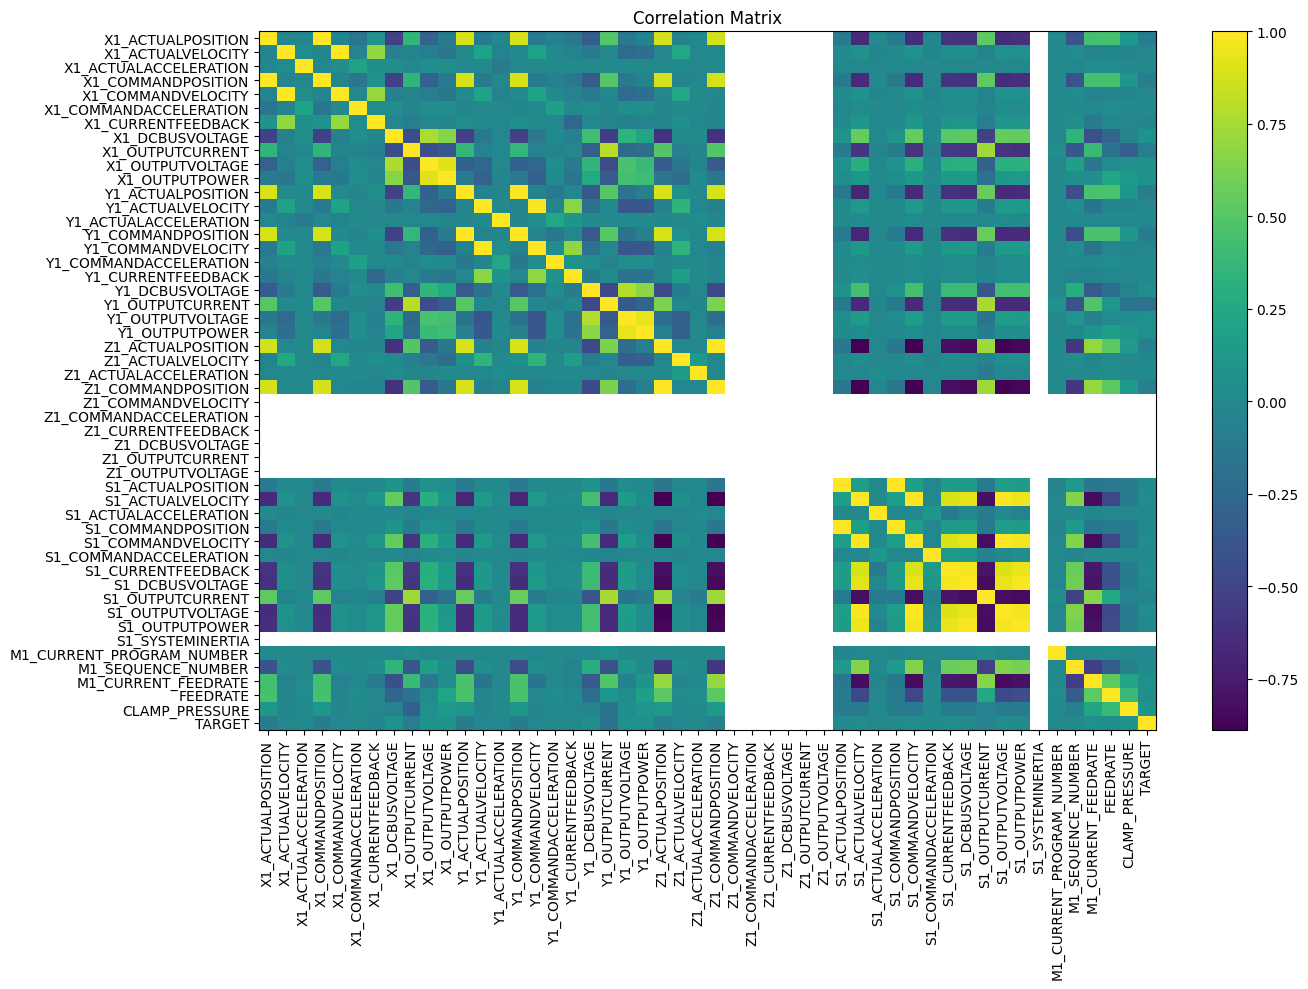

['X1_COMMANDPOSITION', 'X1_COMMANDVELOCITY', 'Y1_COMMANDPOSITION', 'Y1_COMMANDVELOCITY', 'Z1_COMMANDPOSITION', 'S1_COMMANDPOSITION', 'S1_COMMANDVELOCITY', 'S1_DCBUSVOLTAGE', 'S1_OUTPUTVOLTAGE', 'S1_OUTPUTPOWER']


In [ ]:
# 9. Correlation Matrix
def high_correlated_cols(dataframe, plot=False, corr_th=0.90):
    """
    This function returns the columns that have a correlation higher than the threshold value.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    plot : bool, optional
        The default is False.
    corr_th : float, optional
        The default is 0.90.
    Returns
    -------
    drop_list : list
        The list of columns that have a correlation higher than the threshold value.
    """
    corr = dataframe.corr(numeric_only=True)
    cor_matrix = corr.abs()
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]
    if plot:
        import seaborn as sns
        import matplotlib.pyplot as plt
        sns.set(rc={'figure.figsize': (15, 15)})
        sns.heatmap(corr, cmap="RdBu")
        plt.show()
    return drop_list

df_corr = df.corr(numeric_only=True)

#print
print("\nCorrelation matrix:")
print(df_corr)



# Plot correlation matrix

plt.figure(figsize=(14, 10))

plt.imshow(df_corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(df_corr.columns)),
    df_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(df_corr.columns)),
    df_corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()



drop_corr_list=high_correlated_cols(df, plot=False, corr_th=0.95) # 0.95 selected since it is meaningful in statisticaly
print(drop_corr_list)

In [ ]:
# Drop List
"""
['X1_COMMANDPOSITION', 'X1_COMMANDVELOCITY', 'Y1_COMMANDPOSITION',
'Y1_COMMANDVELOCITY', 'Z1_COMMANDPOSITION', 'S1_COMMANDPOSITION',
'S1_COMMANDVELOCITY', 'S1_DCBUSVOLTAGE', 'S1_OUTPUTVOLTAGE', 'S1_OUTPUTPOWER']
"""

"\n['X1_COMMANDPOSITION', 'X1_COMMANDVELOCITY', 'Y1_COMMANDPOSITION', \n'Y1_COMMANDVELOCITY', 'Z1_COMMANDPOSITION', 'S1_COMMANDPOSITION', \n'S1_COMMANDVELOCITY', 'S1_DCBUSVOLTAGE', 'S1_OUTPUTVOLTAGE', 'S1_OUTPUTPOWER']\n"

In [ ]:
print(df.shape) # (25286, 41)
# df.drop(drop_corr_list, axis=1, inplace=True)
print(df.shape) # (25286, 31)


(25286, 51)
(25286, 51)


<Figure size 700x400 with 0 Axes>

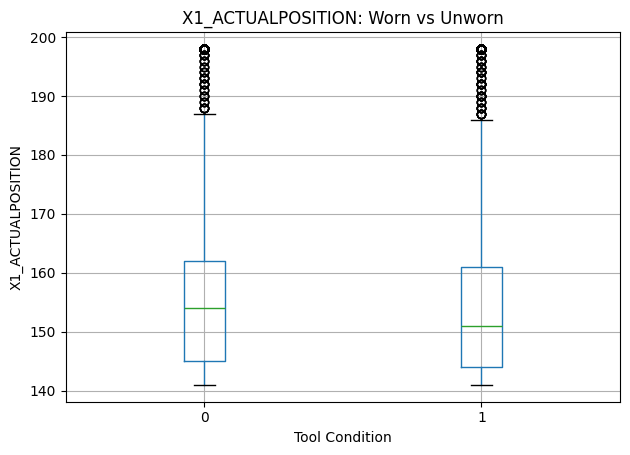

<Figure size 700x400 with 0 Axes>

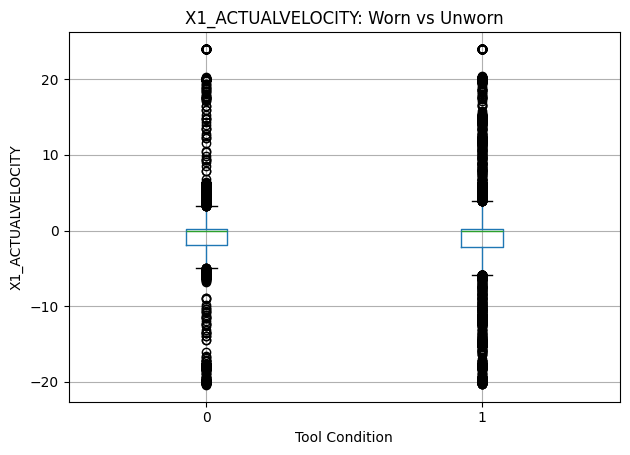

<Figure size 700x400 with 0 Axes>

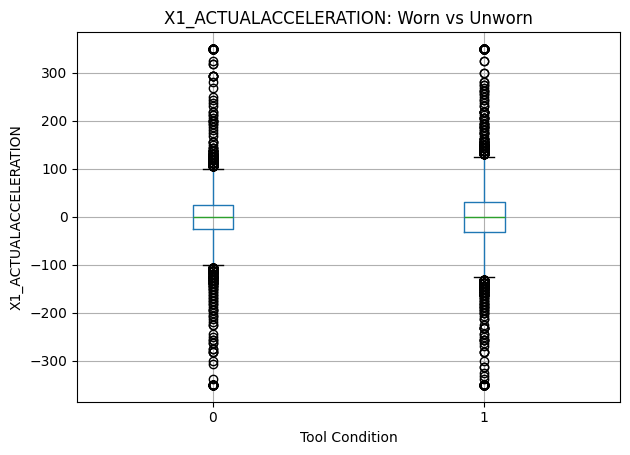

<Figure size 700x400 with 0 Axes>

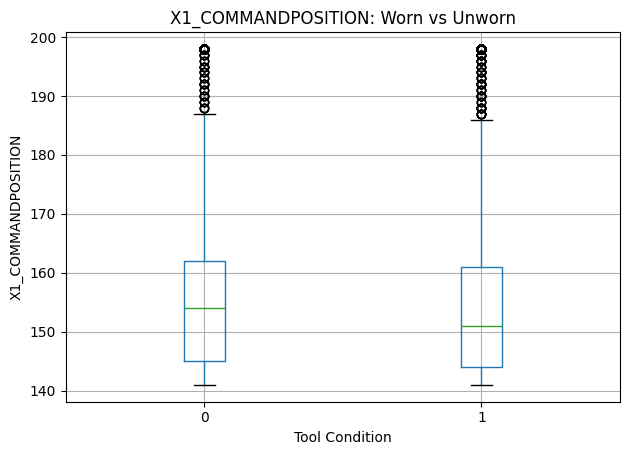

<Figure size 700x400 with 0 Axes>

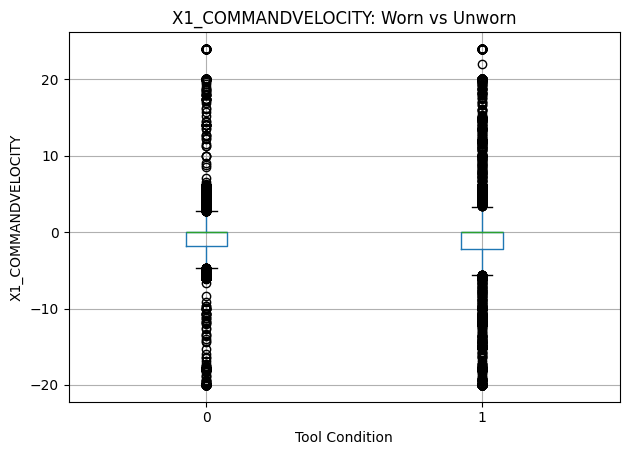

<Figure size 700x400 with 0 Axes>

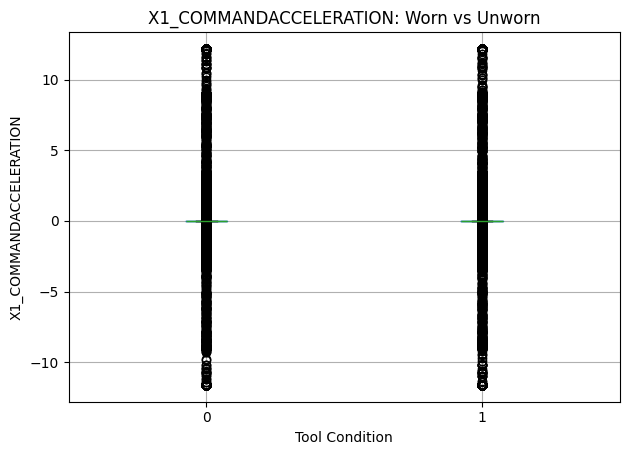

<Figure size 700x400 with 0 Axes>

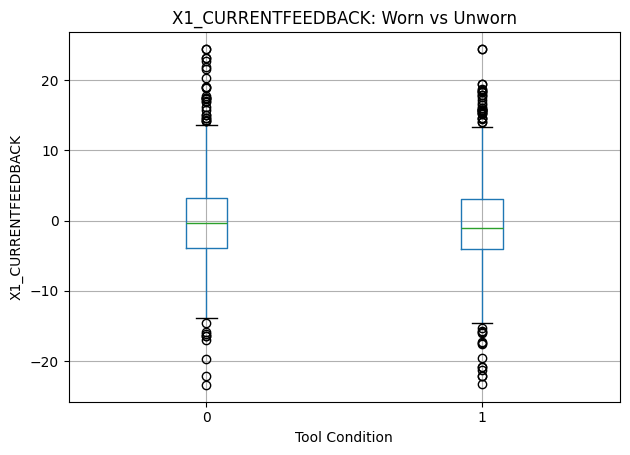

<Figure size 700x400 with 0 Axes>

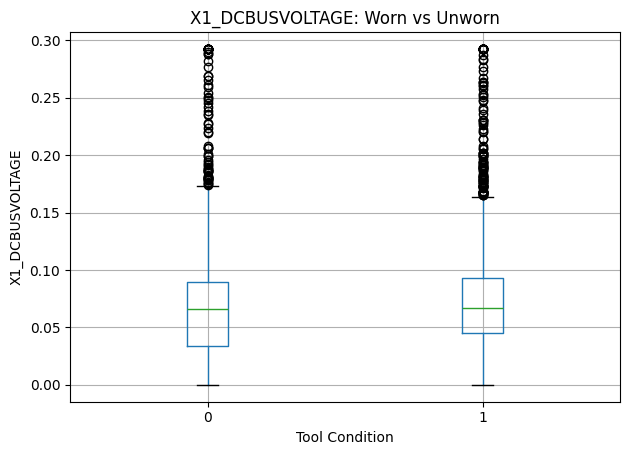

<Figure size 700x400 with 0 Axes>

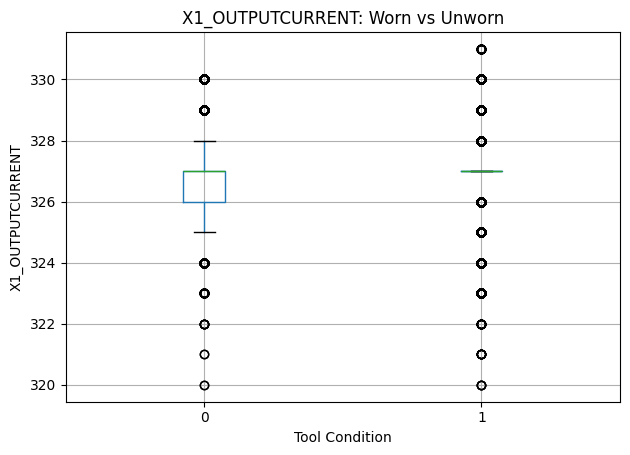

<Figure size 700x400 with 0 Axes>

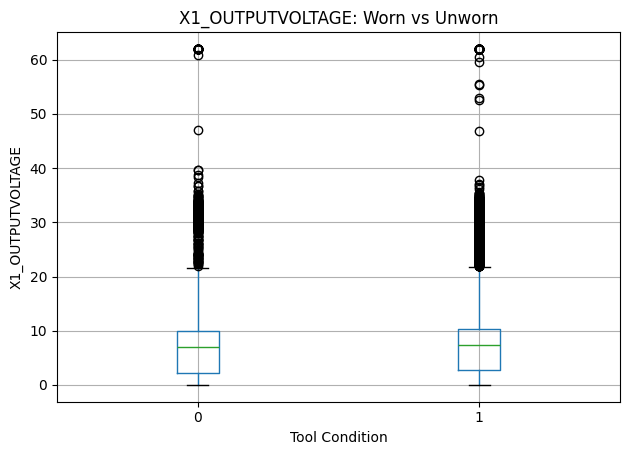

<Figure size 700x400 with 0 Axes>

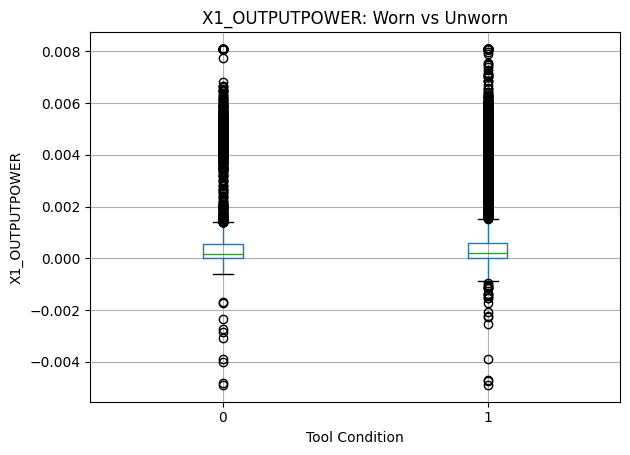

<Figure size 700x400 with 0 Axes>

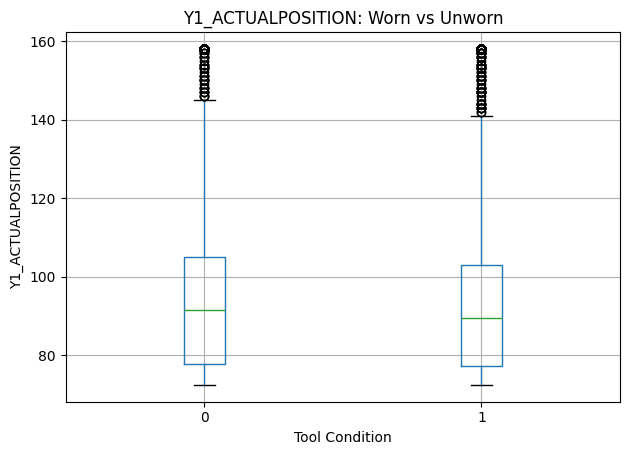

<Figure size 700x400 with 0 Axes>

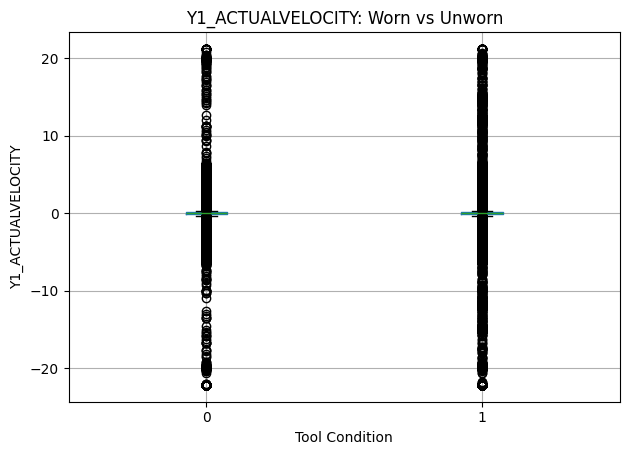

<Figure size 700x400 with 0 Axes>

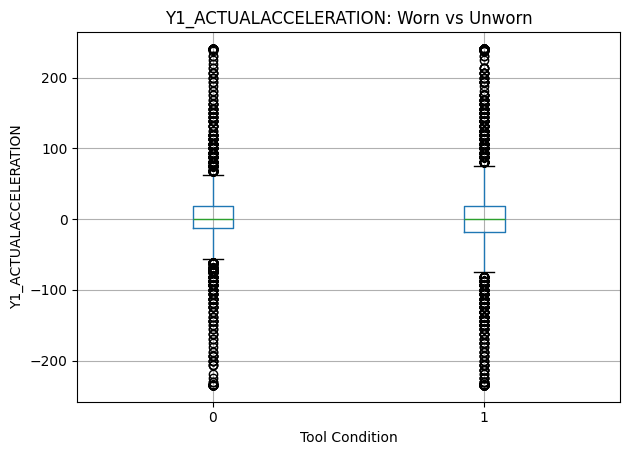

<Figure size 700x400 with 0 Axes>

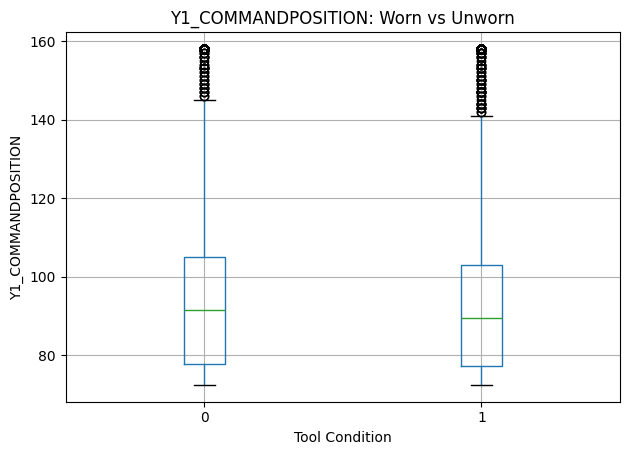

<Figure size 700x400 with 0 Axes>

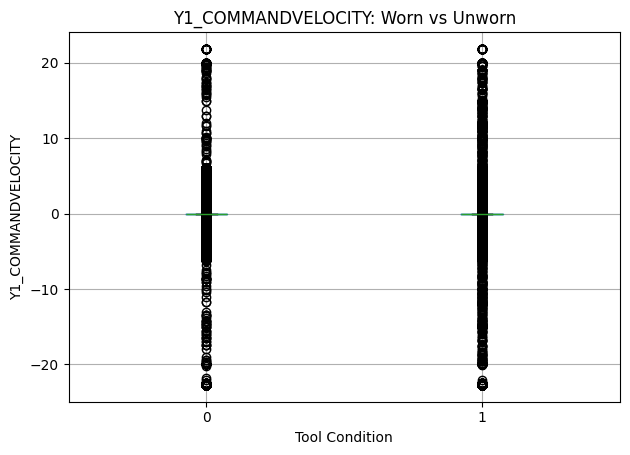

<Figure size 700x400 with 0 Axes>

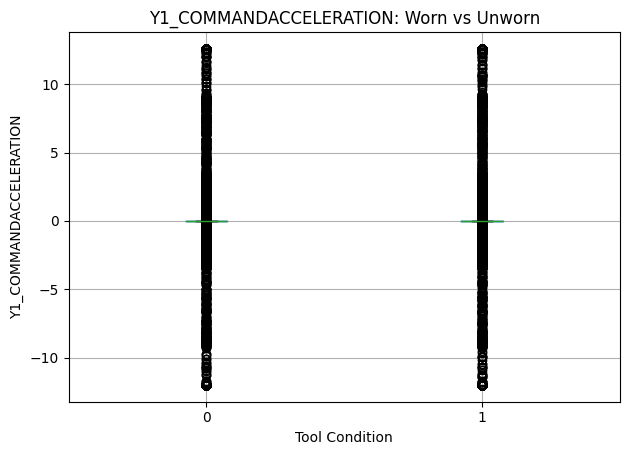

<Figure size 700x400 with 0 Axes>

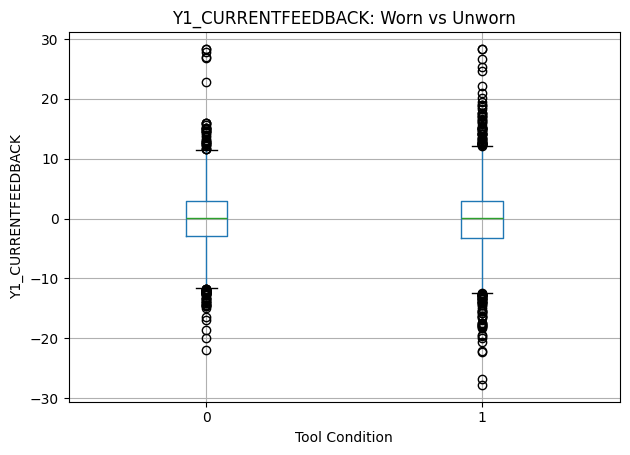

<Figure size 700x400 with 0 Axes>

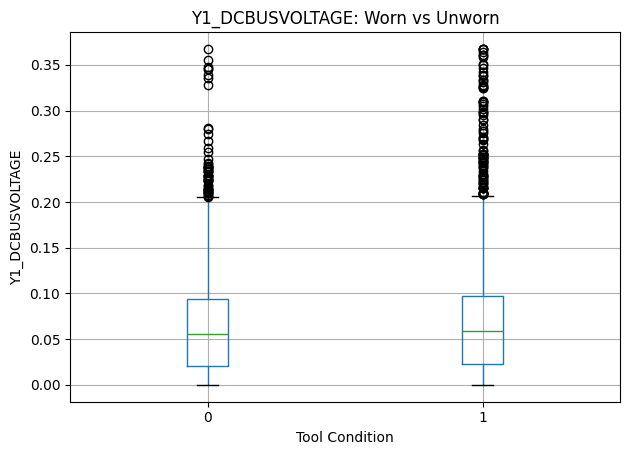

<Figure size 700x400 with 0 Axes>

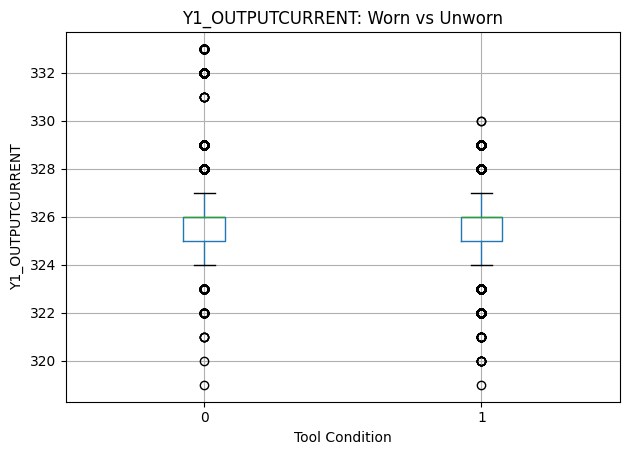

<Figure size 700x400 with 0 Axes>

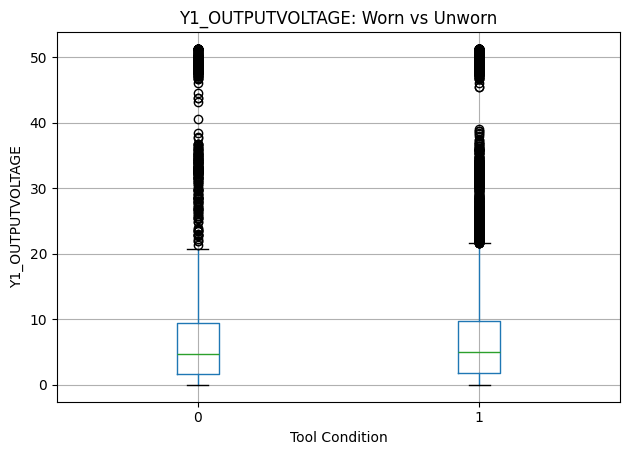

<Figure size 700x400 with 0 Axes>

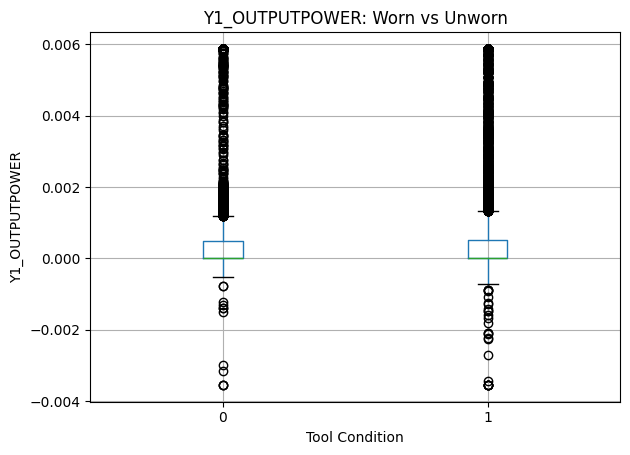

<Figure size 700x400 with 0 Axes>

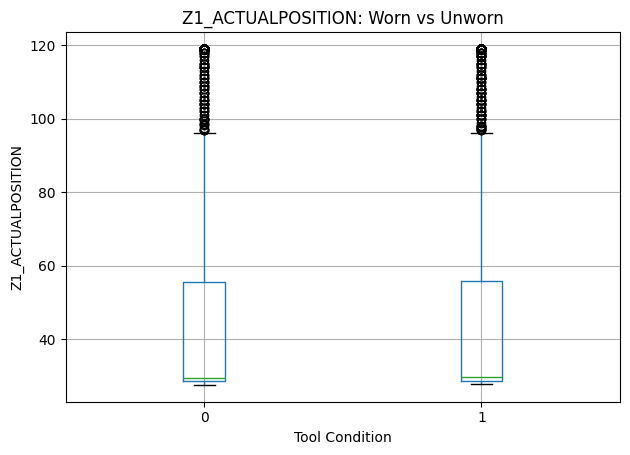

<Figure size 700x400 with 0 Axes>

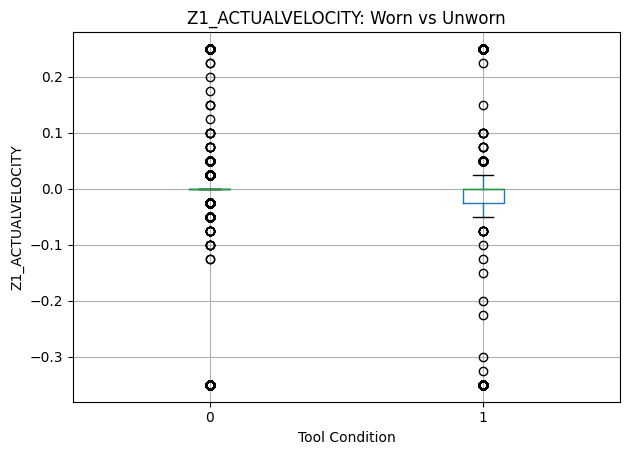

<Figure size 700x400 with 0 Axes>

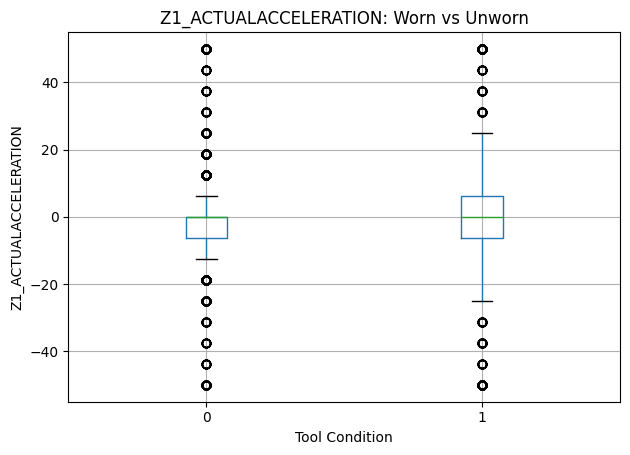

<Figure size 700x400 with 0 Axes>

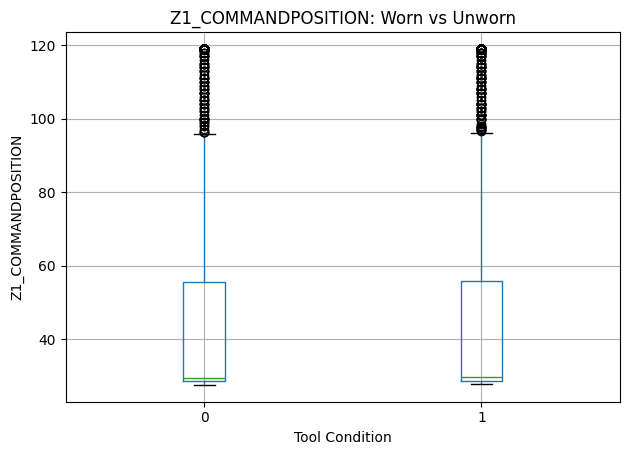

<Figure size 700x400 with 0 Axes>

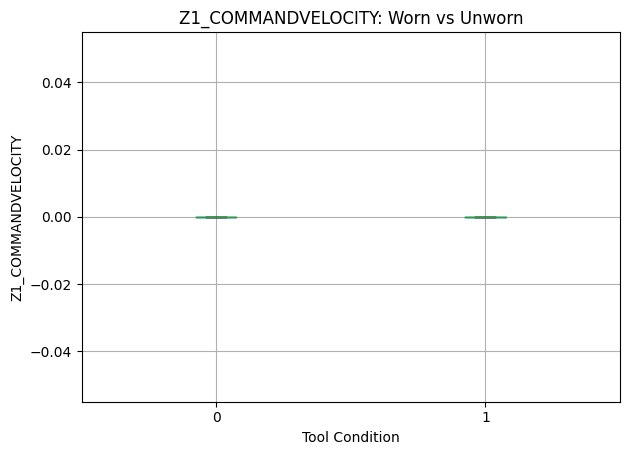

<Figure size 700x400 with 0 Axes>

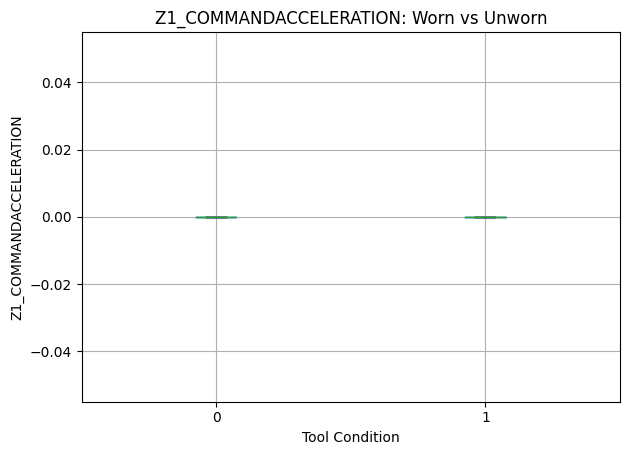

<Figure size 700x400 with 0 Axes>

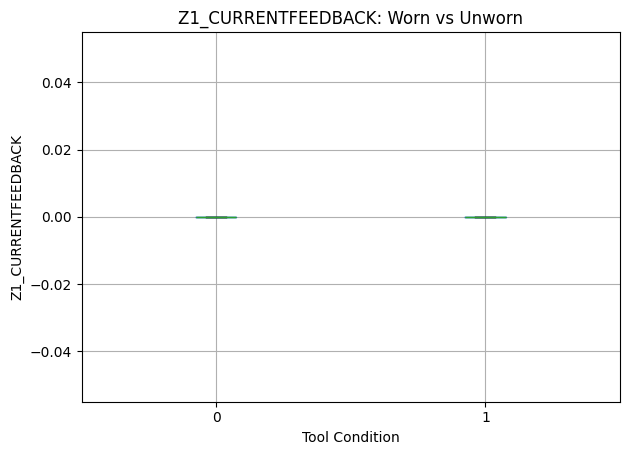

<Figure size 700x400 with 0 Axes>

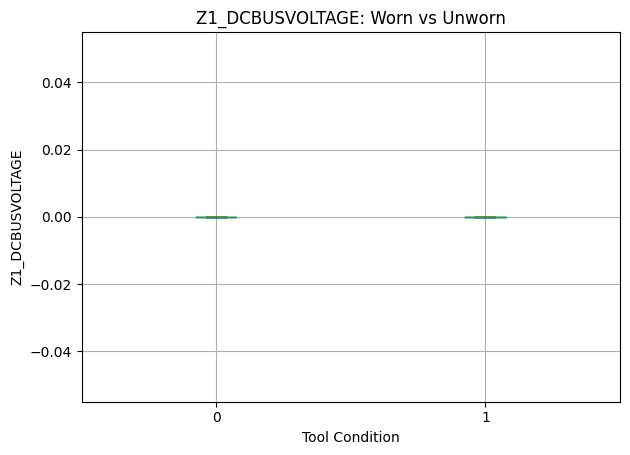

<Figure size 700x400 with 0 Axes>

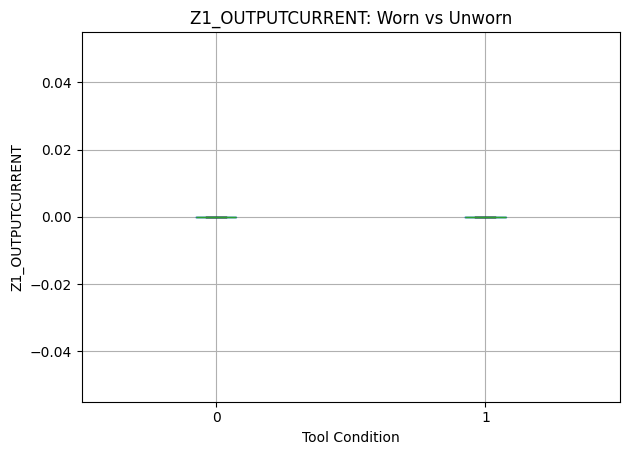

<Figure size 700x400 with 0 Axes>

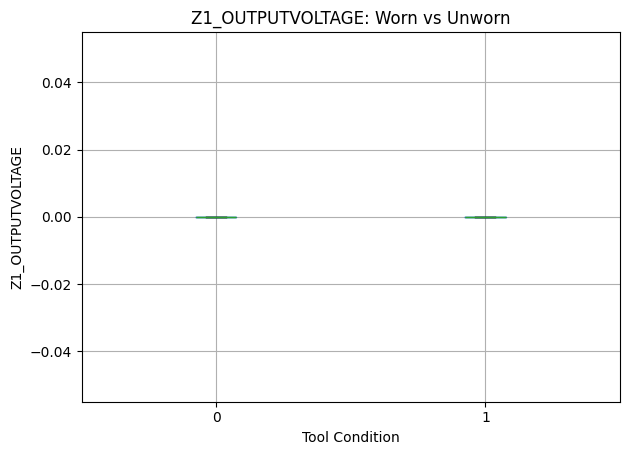

<Figure size 700x400 with 0 Axes>

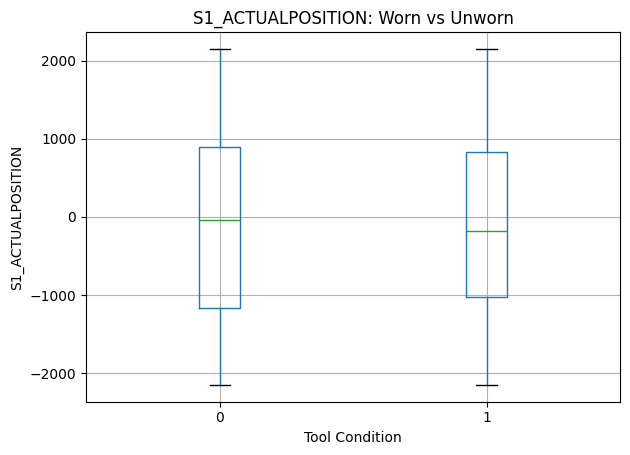

<Figure size 700x400 with 0 Axes>

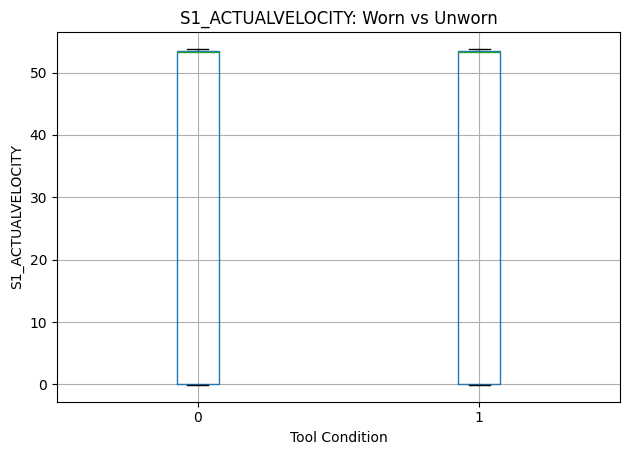

<Figure size 700x400 with 0 Axes>

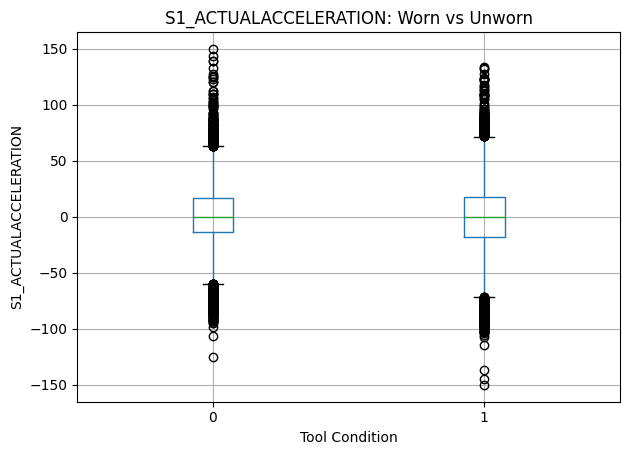

<Figure size 700x400 with 0 Axes>

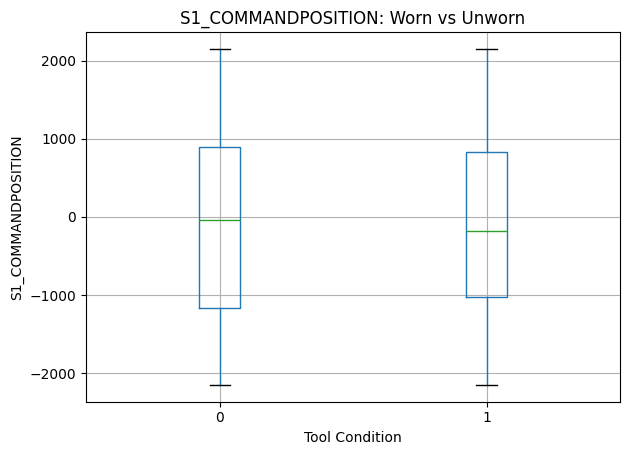

<Figure size 700x400 with 0 Axes>

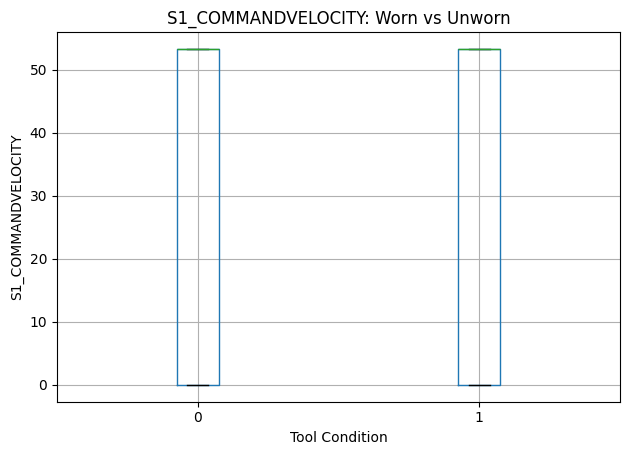

<Figure size 700x400 with 0 Axes>

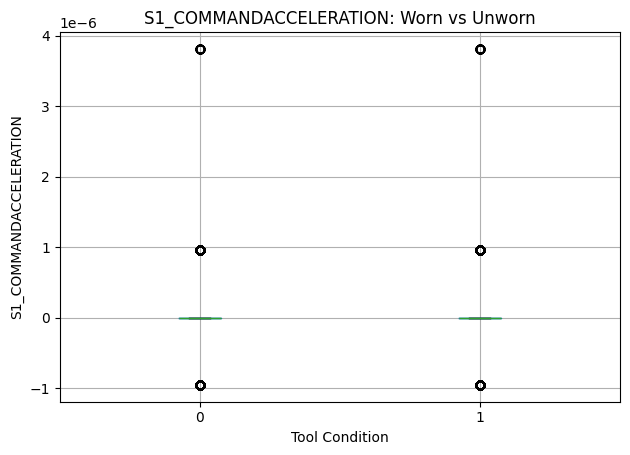

<Figure size 700x400 with 0 Axes>

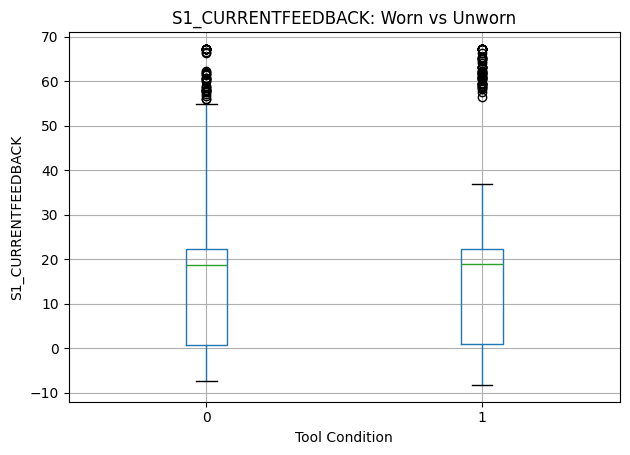

<Figure size 700x400 with 0 Axes>

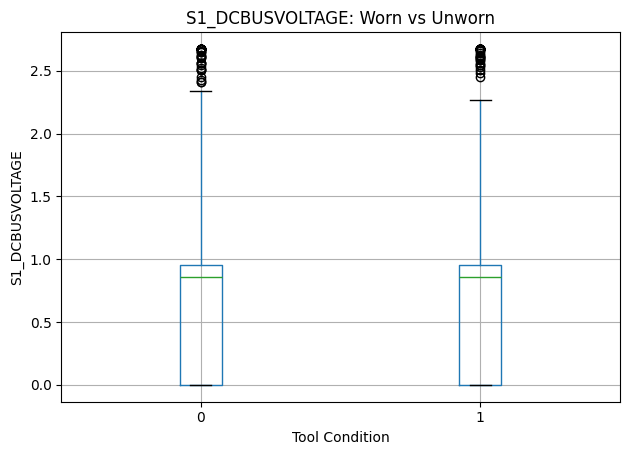

<Figure size 700x400 with 0 Axes>

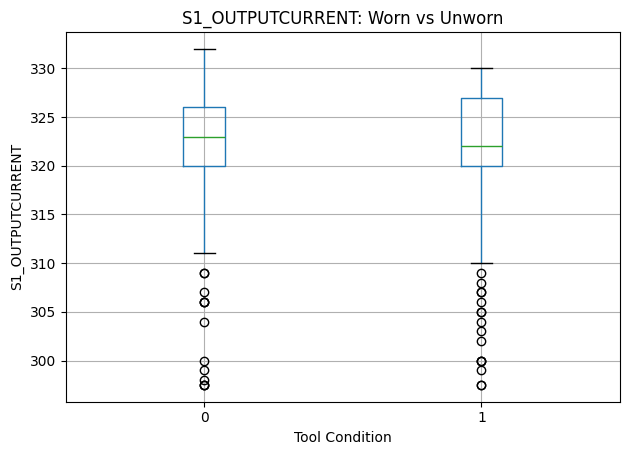

<Figure size 700x400 with 0 Axes>

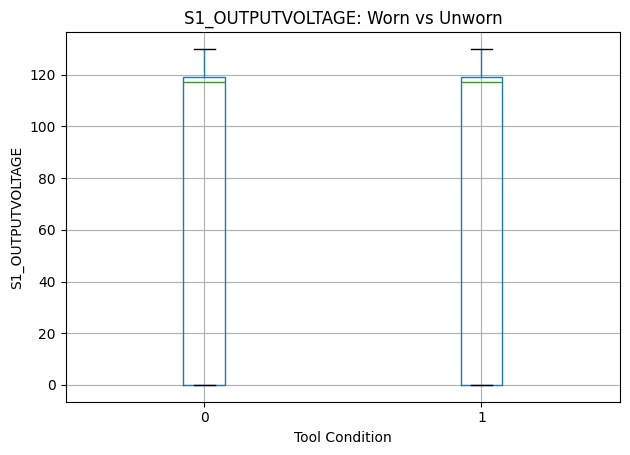

<Figure size 700x400 with 0 Axes>

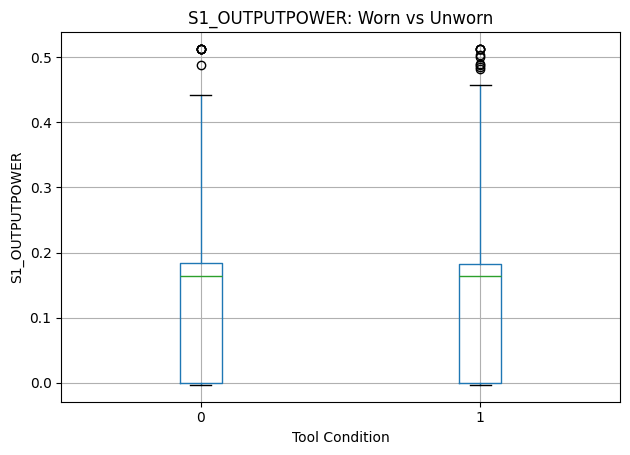

<Figure size 700x400 with 0 Axes>

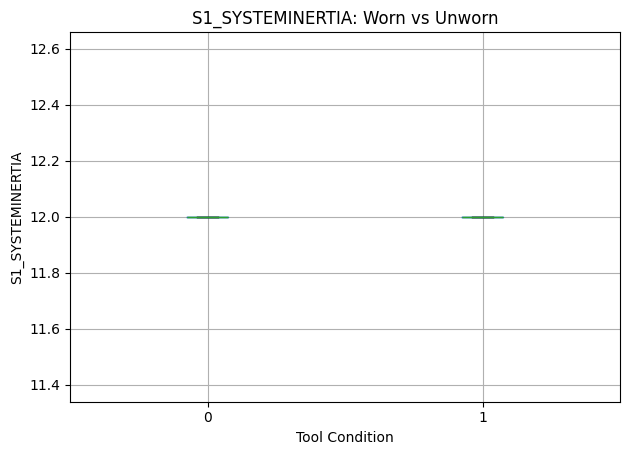

<Figure size 700x400 with 0 Axes>

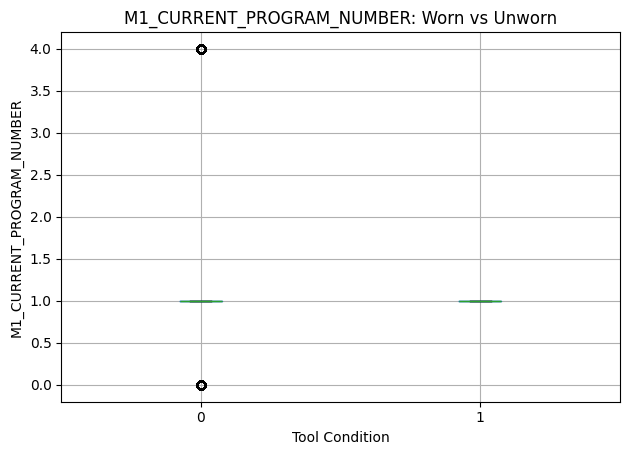

<Figure size 700x400 with 0 Axes>

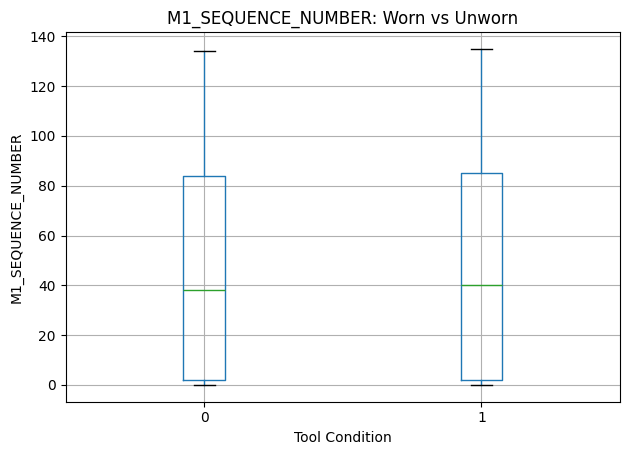

<Figure size 700x400 with 0 Axes>

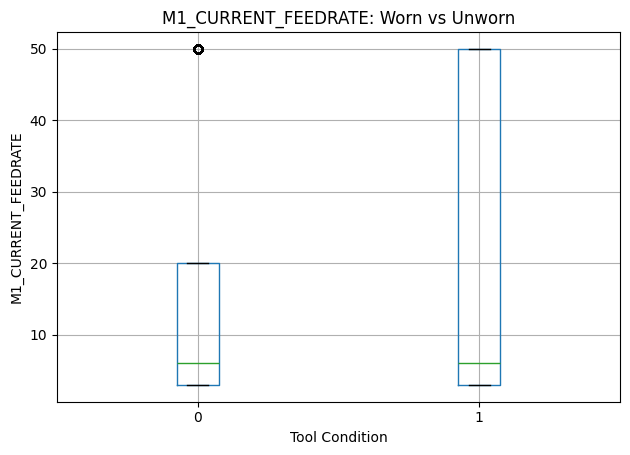

<Figure size 700x400 with 0 Axes>

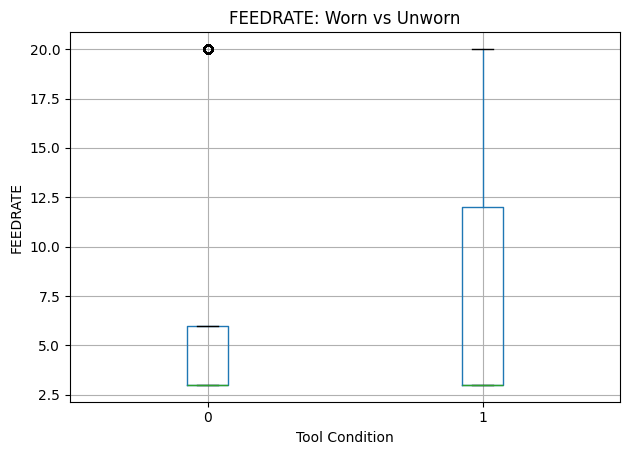

<Figure size 700x400 with 0 Axes>

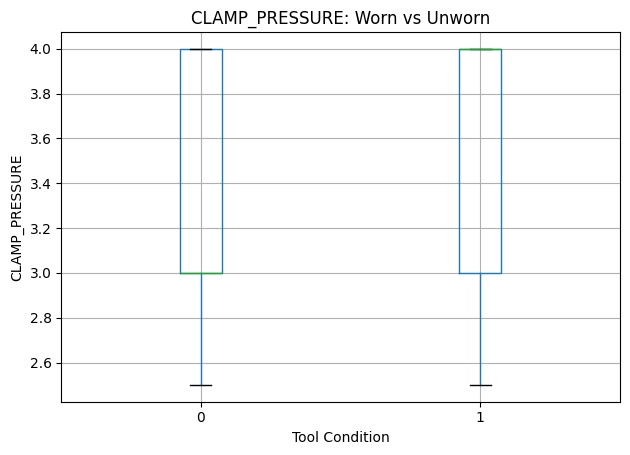

In [ ]:
# ==========================================================
# 14. WORN VS UNWORN COMPARISON
# ==========================================================

# Recompute numeric columns fresh, since df's column names changed
# (uppercased) after earlier cells ran df.columns = df.columns.str.upper()
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Select numerical columns except target itself
features = [
    column
    for column in numeric_columns
    if column != "TARGET"
]

for column in features:

    plt.figure(figsize=(7, 4))

    df.boxplot(
        column=column,
        by="TARGET"
    )

    plt.title(f"{column}: Worn vs Unworn")
    plt.suptitle("")

    plt.xlabel("Tool Condition")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================================
# 18. FINAL SUMMARY
# ==========================================================

print("\n" + "=" * 60)
print("EDA COMPLETED")
print("=" * 60)

print("\nFinal dataset shape:", df.shape)

print("\nTarget distribution:")
print(df["TARGET"].value_counts())

print("\nTotal missing values:",
      df.isnull().sum().sum())

print("\nTotal duplicate rows:",
      df.duplicated().sum())



EDA COMPLETED

Final dataset shape: (25286, 51)

Target distribution:
TARGET
1    13308
0    11978
Name: count, dtype: int64

Total missing values: 0

Total duplicate rows: 331


In [ ]:
#######################################
######### FEATURE ENGINEERING #########
#######################################

# There are 6 steps to be taken in the Feature Engineering process.
# 1. Missing Values
# 2. Outlier Values Analysis
# 3. Feature Generation
# 4. Encoding
# 5. Standardization
# 6. Save the Dataset

# 1. Missing Values
# No missing values in the dataset

# 2. Outlier Values Analysis
# Outliers are handled in the previous steps

# 3. Feature Generation
# It will be implemanted lately after research.

# 4. Encoding
# No need for encoding, there is only one categorical variable (TARGET)
# It is already converted to binary at line 59 --> for with drop_list

cat_cols, num_cols, cat_but_car = grap_column_names(df)

for col in cat_cols:
    cat_cols = [col for col in cat_cols if col not in cat_to_numeric]

for col in cat_to_numeric:
    num_cols.append(col)


cat_cols = [col for col in cat_cols if col not in ["TARGET"]]
print(cat_cols)

def one_hot_encoder(dataframe, categorical_columns, drop_first=True):
    """
    This function encodes the categorical variables to numericals.

    Parameters
    ----------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    categorical_columns : list
        The name of the column to be encoded.
    drop_first : bool, optional
        Dummy trap. The default is True.
    Returns
    -------
    dataframe : pandas dataframe
        The dataframe to be analyzed.
    """
    dataframe = pd.get_dummies(dataframe, columns=categorical_columns, drop_first=drop_first)
    return dataframe

df = one_hot_encoder(df, cat_cols, drop_first=True)

print(df.head())

# 5. Standardization

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print('#'*50)

print(df.head())
print(df.shape)
print(cat_cols)

# 6. Save the Dataset
df.to_csv('aggregated_cleaned.csv', index=False)

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)

# Save train and test sets
test_size = int(0.2 * df.shape[0])
test_data = df[:test_size]
train_data = df[test_size:]

train_data.to_csv('aggregated_train_cleaned.csv', index=False)
print("Train dataset shape: ",train_data.shape)

print("#"*50)

test_data.to_csv('aggregated_test_cleaned.csv', index=False)
print("Test dataset shape: ",test_data.shape)

Observations: 25286
Variables: 61
categorical_cols: 24
num_cols: 37
categorical_but_cardinal: 0
numeric_but_categorical: 24
['MACHINING_PROCESS_Layer 1 Down', 'MACHINING_PROCESS_Layer 1 Up', 'MACHINING_PROCESS_Layer 2 Down', 'MACHINING_PROCESS_Layer 2 Up', 'MACHINING_PROCESS_Layer 3 Down', 'MACHINING_PROCESS_Layer 3 Up', 'MACHINING_PROCESS_Prep', 'MACHINING_PROCESS_Repositioning', 'MACHINING_PROCESS_Starting', 'MACHINING_PROCESS_end', 'M1_CURRENT_PROGRAM_NUMBER_1.0', 'M1_CURRENT_PROGRAM_NUMBER_4.0']
   X1_ACTUALPOSITION  X1_ACTUALVELOCITY  X1_ACTUALACCELERATION  \
0              1.000              0.459                  0.500   
1              1.000              0.216                  0.000   
2              0.965              0.059                  0.491   
3              0.930              0.054                  0.500   
4              0.912              0.056                  0.473   

   X1_COMMANDPOSITION  X1_COMMANDVELOCITY  X1_COMMANDACCELERATION  \
0               1.000        

In [ ]:
########

###Model implementation


   X1_ACTUALPOSITION  X1_ACTUALVELOCITY  X1_ACTUALACCELERATION  \
0              1.000              0.459                  0.500   
1              1.000              0.459                  0.500   
2              0.000              0.458                  0.446   
3              1.000              0.459                  0.491   
4              0.281              0.400                  0.563   

   X1_COMMANDPOSITION  X1_COMMANDVELOCITY  X1_COMMANDACCELERATION  \
0               1.000               0.455                   0.488   
1               1.000               0.455                   0.488   
2               0.000               0.455                   0.488   
3               1.000               0.455                   0.488   
4               0.281               0.390                   0.457   

   X1_CURRENTFEEDBACK  X1_DCBUSVOLTAGE  X1_OUTPUTCURRENT  X1_OUTPUTVOLTAGE  \
0               0.476            0.078             0.909             0.013   
1               0.492           

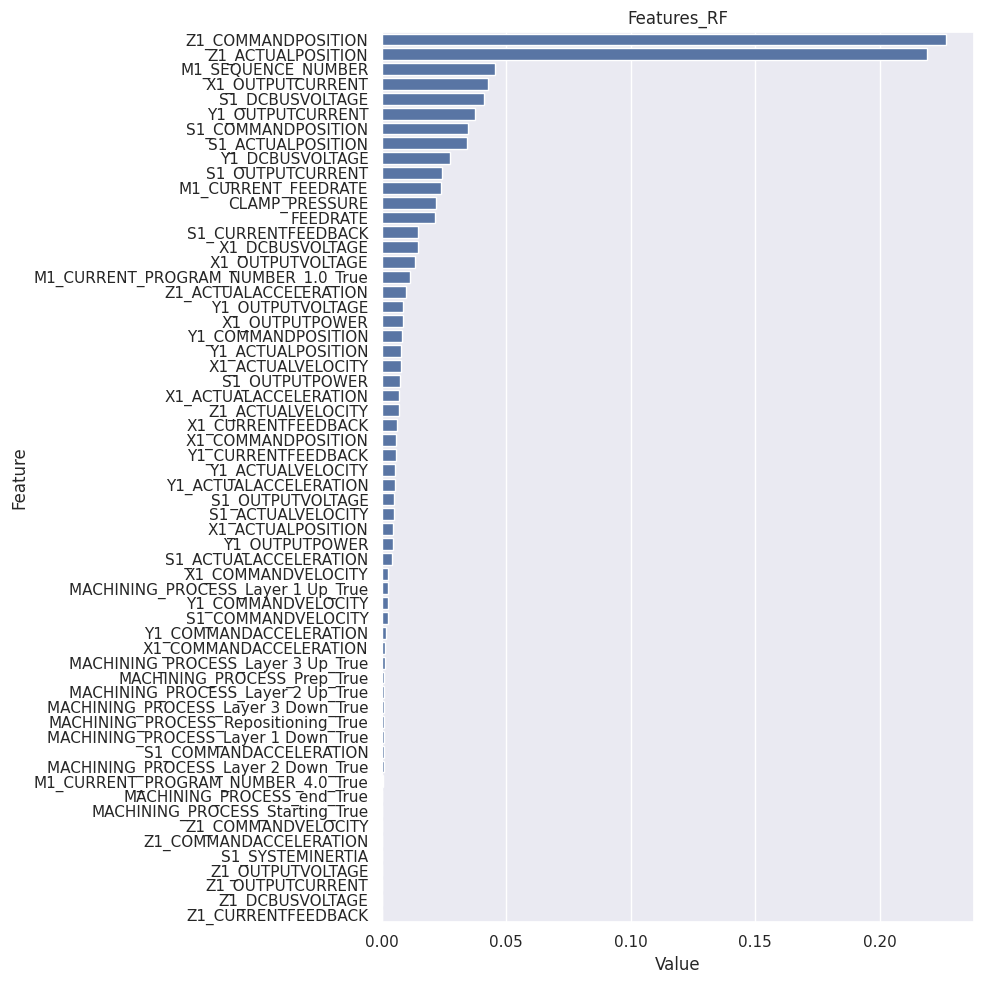

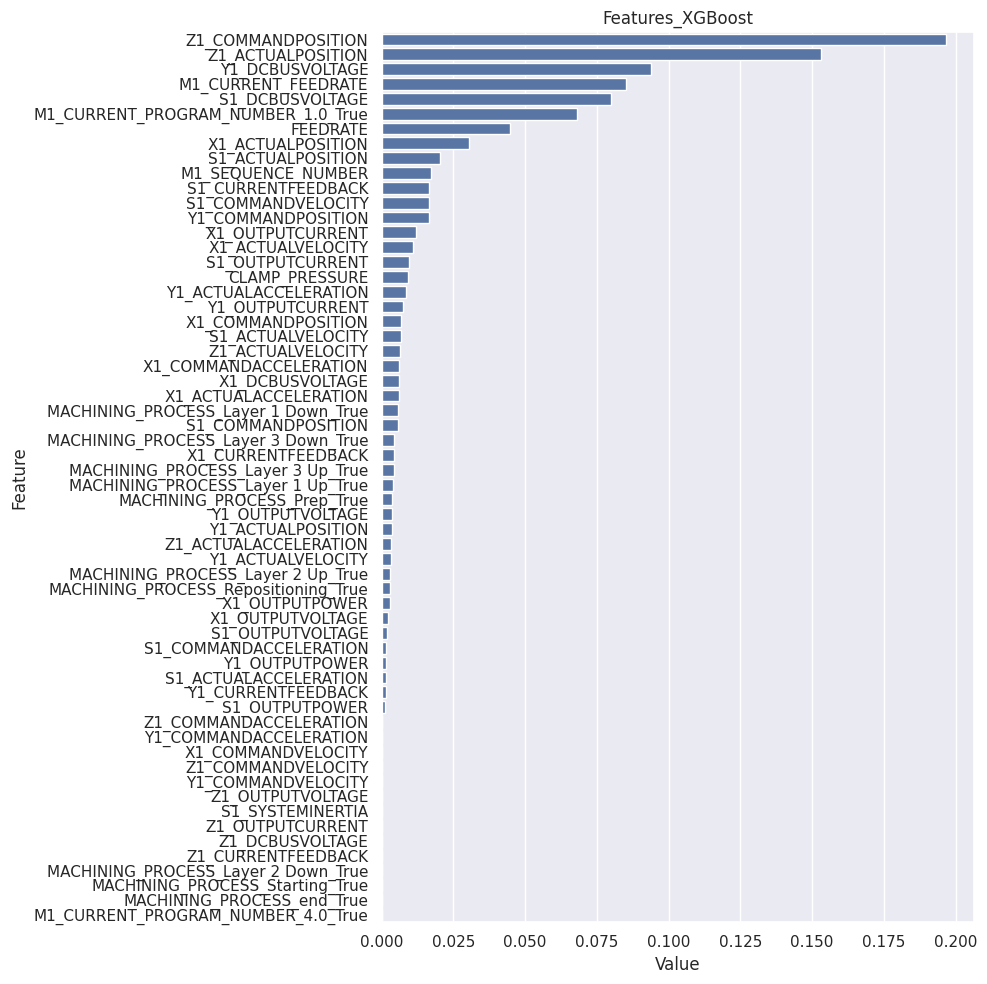

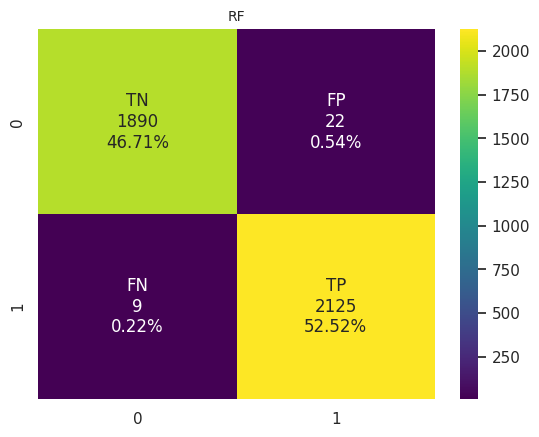

              precision    recall  f1-score   support

      Unworn     0.9953    0.9885    0.9919      1912
        Worn     0.9898    0.9958    0.9928      2134

    accuracy                         0.9923      4046
   macro avg     0.9925    0.9921    0.9923      4046
weighted avg     0.9924    0.9923    0.9923      4046



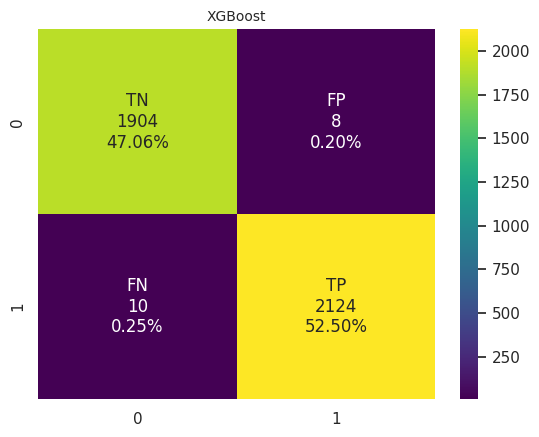

              precision    recall  f1-score   support

      Unworn     0.9948    0.9958    0.9953      1912
        Worn     0.9962    0.9953    0.9958      2134

    accuracy                         0.9956      4046
   macro avg     0.9955    0.9956    0.9955      4046
weighted avg     0.9956    0.9956    0.9956      4046

Voting Classifier...
Accuracy: 0.9946240032870858
F1Score: 0.9949115003621405
ROC_AUC: 0.9998756063834339
              precision    recall  f1-score   support

      Unworn     0.9953    0.9958    0.9956      1912
        Worn     0.9962    0.9958    0.9960      2134

    accuracy                         0.9958      4046
   macro avg     0.9958    0.9958    0.9958      4046
weighted avg     0.9958    0.9958    0.9958      4046



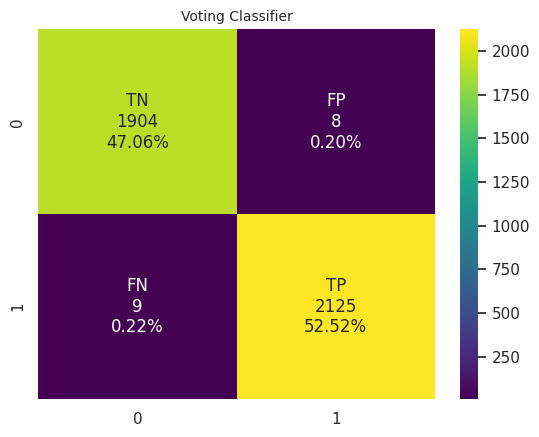

In [ ]:
!pip install catboost

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
from shutil import get_terminal_size

from sklearn.model_selection import train_test_split, cross_validate, validation_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib

import os
os.makedirs('models', exist_ok=True)

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) # Show all the columns
pd.set_option('display.max_rows', None) # Show all the rows
pd.set_option('max_colwidth', None) # Show all the text in the columns
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Show all the decimals
pd.set_option('display.width', get_terminal_size()[0]) # Get bigger terminal display width

# Load the data
# df = pd.read_csv('dataset/combined_cleaned.csv') # Dropped_list
df = pd.read_csv('aggregated_train_cleaned.csv')

print(df.head())
print(df.dtypes)
#######################################
#### MODEL BUILDING AND EVALUATION ####
#######################################

# 1. Base Models
# 2. Automated Hyperparameter Optimization
# 3. Stacking & Ensemble Learning

# 1. Split Dataset

X = df.drop('TARGET', axis=1)
y = df['TARGET']

# 2.1 without stratify
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


def base_models(X, y, scoring="roc_auc", cv=5, all_metrics=False):
    print("Base Models....")
    classifiers = [("RF", RandomForestClassifier()),
                   ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
                   ]

    if (all_metrics == True):
        for name, classifier in classifiers:
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name}) ")
            print(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name}) ")
            print(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name}) ")

            f = open('Estimators_BaseModels.txt', 'a')
            f.writelines(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name})\n")
            f.writelines(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name})\n")
            f.writelines(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name})\n")
            f.close()

    else:
        for name, classifier in classifiers:
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"{scoring}: {round(cv_results['test_score'].mean(), 4)} ({name}) ")

            f = open('Estimators.txt', 'a')
            f.writelines(f"Score: {round(cv_results['test_score'].mean(), 4)} ({name})\n")
            f.close()

# 1st Approach feed with all data
# base_models(X, y, scoring=["accuracy", "f1", "roc_auc" ], all_metrics=True)

# 2nd Approach feed with train data
base_models(X_train, y_train, scoring=["accuracy", "f1", "roc_auc" ], cv=5, all_metrics=True)

# 2. Automated Hyperparameter Optimization
#knn_params = {"n_neighbors": range(2, 50)}

#cart_params = {'max_depth': range(1, 20),
 #              "min_samples_split": range(2, 30)}

rf_params = {"max_depth": [8, 15, None],
             "max_features": [5, 7, "auto"],
            "min_samples_split": [15, 20],
             "n_estimators": [200, 300]}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8],
                  "n_estimators": [100, 200]}

#lightgbm_params = {"learning_rate": [0.01, 0.1],
 #                  "n_estimators": [300, 500]}

classifiers = [("RF", RandomForestClassifier(), rf_params),
                ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss'), xgboost_params)
               ]

def hyperparameter_optimization(X, y, classifiers, cv=5, scoring="roc_auc", all_metrics=False):
    print("Hyperparameter Optimization....")
    best_models = {}

    if (all_metrics == True):
        for name, classifier, params in classifiers:
            print(f"########## {name} ##########")
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"Accuracy (Before): {round(cv_results['test_accuracy'].mean(), 4)}")
            print(f"F1 (Before): {round(cv_results['test_f1'].mean(), 4)}")
            print(f"ROC_AUC (Before): {round(cv_results['test_roc_auc'].mean(), 4)}")

            gs_best = GridSearchCV(classifier, params, cv=cv, n_jobs=-1, verbose=False).fit(X, y)
            final_model = classifier.set_params(**gs_best.best_params_)

            cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name}) ")
            print(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name}) ")
            print(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name})")
            print(f"{name} best params: {gs_best.best_params_}", end="\n\n")

            f = open('Estimators_Hyperparameter.txt', 'a')
            f.writelines(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name})\n")
            f.writelines(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name})\n")
            f.writelines(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name})\n")
            f.writelines(f"{name} best params: {gs_best.best_params_}\n")
            f.close()

            best_models[name] = final_model
    else:
        for name, classifier, params in classifiers:
            print(f"########## {name} ##########")
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring)
            print(f"{scoring} (Before): {round(cv_results['test_score'].mean(), 4)}")

            gs_best = GridSearchCV(classifier, params, cv=cv, n_jobs=-1, verbose=False).fit(X, y)
            final_model = classifier.set_params(**gs_best.best_params_)

            cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring)

            print(f"{scoring} (After): {round(cv_results['test_score'].mean(), 4)}")
            print(f"{name} best params: {gs_best.best_params_}", end="\n\n")

            f = open('Estimators_Hyperparameter.txt', 'a')
            f.writelines(f"{scoring} (After): {round(cv_results['test_score'].mean(), 4)}\n")
            f.writelines(f"{name} best params: {gs_best.best_params_}\n")
            f.close()
            best_models[name] = final_model
    return best_models

# best_models = hyperparameter_optimization(X, y, classifiers=classifiers, cv=5, scoring=["accuracy", "f1", "roc_auc" ], all_metrics=True)

best_models = hyperparameter_optimization(X_train, y_train, classifiers=classifiers, cv=5, scoring=["accuracy", "f1", "roc_auc" ], all_metrics=True)

"""
print(best_models["CART"].fit(X,y).feature_importances_)
print(best_models["RF"].fit(X,y).feature_importances_)
print(best_models["XGBoost"].fit(X,y).feature_importances_)
print(best_models["LightGBM"].fit(X,y).feature_importances_)
"""

################################
### PLOT- FEATURE IMPORTANCE ###
################################

def plot_importance(model, features, name, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features_{}'.format(name))
    plt.tight_layout()
    if save:
        plt.savefig('importances_{}.png'.format(name))
    plt.show()

for model in best_models:
    if model != "KNN":
        final_model = best_models[model].fit(X_train, y_train)
        plot_importance(final_model, X_train, name = model, save=True)
    else:
        pass

##############################
### PLOT- CONFUSION MATRIX ###
##############################
def plot_confusion_matrix(name, y_actual, y_pred, cmap='viridis', save=False):
    cm = confusion_matrix(y_actual, y_pred)

    group_names = ['TN','FP','FN','TP']
    group_counts = ['{0:0.0f}'.format(value) for value in
                    cm.flatten()]
    group_percentages = ['{0:.2%}'.format(value) for value in
                        cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
            zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap)
    plt.title('{}'.format(name), fontsize=10)
    if save:
        plt.savefig('confusion_matrix_{}.png'.format(name))
        plt.savefig('confusion_matrix_{}.tiff'.format(name))
    plt.show()

def classification_report_output(name, y_actual, y_pred, target_names=None):

    print(classification_report(y_true=y_actual, y_pred=y_pred,
                                digits=4, target_names=target_names))

    f = open('classification_report.txt', 'a')
    f.writelines(f"########## {name} ##########\n")
    f.writelines(f"{classification_report(y_true=y_actual, y_pred=y_pred, digits=4, target_names=target_names)}\n")
    f.writelines(f"############################\n")
    f.close()

for model in best_models:
    model_fit=best_models[model].fit(X_train, y_train)

    plot_confusion_matrix(name=model,
                          y_actual=y_test,
                          y_pred=model_fit.predict(X_test),
                          save=True)

    # 0 = Unworn, 1 = Worn --> from tool_wear_detection_research.py line 59
    classification_report_output(name=model,
                            y_actual=y_test,
                            y_pred=model_fit.predict(X_test), target_names=["Unworn","Worn"])

def val_curve_params(model, X, y, param_name, param_range, scoring="roc_auc", cv=5):
    train_score, test_score = validation_curve(
        model, X=X, y=y, param_name=param_name, param_range=param_range, scoring=scoring, cv=cv)

    mean_train_score = np.mean(train_score, axis=1)
    mean_test_score = np.mean(test_score, axis=1)

    plt.plot(param_range, mean_train_score,
             label="Training Score", color='b')

    plt.plot(param_range, mean_test_score,
             label="Validation Score", color='g')

    plt.title(f"Validation Curve for {type(model).__name__}")
    plt.xlabel(f"Number of {param_name}")
    plt.ylabel(f"{scoring}")
    plt.tight_layout()
    plt.legend(loc='best')
    plt.savefig(f"Validation Curve for {type(model).__name__}.png")
    plt.show(block=True)

def voting_classifier(best_models, X, y, cv=5):
    print("Voting Classifier...")
    voting_clf = VotingClassifier(estimators=[('RF', best_models["RF"]),
                                              ('XGBoost', best_models["XGBoost"])],
                                  voting='soft').fit(X, y)
    cv_results = cross_validate(voting_clf, X, y, cv=cv, scoring=["accuracy", "f1", "roc_auc"])
    print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
    print(f"F1Score: {cv_results['test_f1'].mean()}")
    print(f"ROC_AUC: {cv_results['test_roc_auc'].mean()}")

    f = open('Ensemble_Results.txt', 'a')

    f.writelines(f"Accuracy: {cv_results['test_accuracy'].mean()}\n")
    f.writelines(f"F1Score: {cv_results['test_f1'].mean()}\n")
    f.writelines(f"ROC_AUC: {cv_results['test_roc_auc'].mean()}\n")
    f.close()

    return voting_clf

voting_clf=voting_classifier(best_models=best_models, X=X_train, y=y_train, cv=5)

classification_report_output(name="Voting Classifier",
                            y_actual=y_test,
                            y_pred=voting_clf.predict(X_test), target_names=["Unworn","Worn"])

plot_confusion_matrix(name="Voting Classifier",
                          y_actual=y_test,
                          y_pred=voting_clf.predict(X_test),
                          save=True)




In [ ]:
###################
### Save Models ###
###################

joblib.dump(best_models["XGBoost"], "models/xgboost_model.pkl")
joblib.dump(best_models["RF"], "models/rf_model.pkl")
#joblib.dump(best_models["LightGBM"], "models/lightgbm_model.pkl")
joblib.dump(voting_clf, "models/voting_clf.pkl")


['models/voting_clf.pkl']

In [ ]:
"""!pip install catboost

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
from shutil import get_terminal_size

from sklearn.model_selection import train_test_split, cross_validate, validation_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) # Show all the columns
pd.set_option('display.max_rows', None) # Show all the rows
pd.set_option('max_colwidth', None) # Show all the text in the columns
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Show all the decimals
pd.set_option('display.width', get_terminal_size()[0]) # Get bigger terminal display width

# Load the data
# df = pd.read_csv('dataset/combined_cleaned.csv') # Dropped_list
df = pd.read_csv('aggregated_train_cleaned.csv')

print(df.head())
print(df.dtypes)
#######################################
#### MODEL BUILDING AND EVALUATION ####
#######################################

# 1. Base Models
# 2. Automated Hyperparameter Optimization
# 3. Stacking & Ensemble Learning

# 1. Split Dataset

X = df.drop('TARGET', axis=1)
y = df['TARGET']

# 2.1 without stratify
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


def base_models(X, y, scoring="roc_auc", cv=5, all_metrics=False):
    print("Base Models....")
    classifiers = [("RF", RandomForestClassifier()),
                   ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
                   ]

    if (all_metrics == True):
        for name, classifier in classifiers:
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name}) ")
            print(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name}) ")
            print(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name}) ")

            f = open('Estimators_BaseModels.txt', 'a')
            f.writelines(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name})\n")
            f.writelines(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name})\n")
            f.writelines(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name})\n")
            f.close()

    else:
        for name, classifier in classifiers:
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"{scoring}: {round(cv_results['test_score'].mean(), 4)} ({name}) ")

            f = open('Estimators.txt', 'a')
            f.writelines(f"Score: {round(cv_results['test_score'].mean(), 4)} ({name})\n")
            f.close()

# 1st Approach feed with all data
# base_models(X, y, scoring=["accuracy", "f1", "roc_auc" ], all_metrics=True)

# 2nd Approach feed with train data
base_models(X_train, y_train, scoring=["accuracy", "f1", "roc_auc" ], cv=5, all_metrics=True)

# 2. Automated Hyperparameter Optimization
#knn_params = {"n_neighbors": range(2, 50)}

#cart_params = {'max_depth': range(1, 20),
 #              "min_samples_split": range(2, 30)}

rf_params = {"max_depth": [8, 15, None],
             "max_features": [5, 7, "auto"],
            "min_samples_split": [15, 20],
             "n_estimators": [200, 300]}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8],
                  "n_estimators": [100, 200]}

#lightgbm_params = {"learning_rate": [0.01, 0.1],
 #                  "n_estimators": [300, 500]}

classifiers = [("RF", RandomForestClassifier(), rf_params),
                ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss'), xgboost_params)
               ]

def hyperparameter_optimization(X, y, classifiers, cv=5, scoring="roc_auc", all_metrics=False):
    print("Hyperparameter Optimization....")
    best_models = {}

    if (all_metrics == True):
        for name, classifier, params in classifiers:
            print(f"########## {name} ##########")
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"Accuracy (Before): {round(cv_results['test_accuracy'].mean(), 4)}")
            print(f"F1 (Before): {round(cv_results['test_f1'].mean(), 4)}")
            print(f"ROC_AUC (Before): {round(cv_results['test_roc_auc'].mean(), 4)}")

            gs_best = GridSearchCV(classifier, params, cv=cv, n_jobs=-1, verbose=False).fit(X, y)
            final_model = classifier.set_params(**gs_best.best_params_)

            cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

            print(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name}) ")
            print(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name}) ")
            print(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name})")
            print(f"{name} best params: {gs_best.best_params_}", end="\n\n")

            f = open('Estimators_Hyperparameter.txt', 'a')
            f.writelines(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 4)} ({name})\n")
            f.writelines(f"F1: {round(cv_results['test_f1'].mean(), 4)} ({name})\n")
            f.writelines(f"ROC_AUC: {round(cv_results['test_roc_auc'].mean(), 4)} ({name})\n")
            f.writelines(f"{name} best params: {gs_best.best_params_}\n")
            f.close()

            best_models[name] = final_model
    else:
        for name, classifier, params in classifiers:
            print(f"########## {name} ##########")
            cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring)
            print(f"{scoring} (Before): {round(cv_results['test_score'].mean(), 4)}")

            gs_best = GridSearchCV(classifier, params, cv=cv, n_jobs=-1, verbose=False).fit(X, y)
            final_model = classifier.set_params(**gs_best.best_params_)

            cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring)

            print(f"{scoring} (After): {round(cv_results['test_score'].mean(), 4)}")
            print(f"{name} best params: {gs_best.best_params_}", end="\n\n")

            f = open('Estimators_Hyperparameter.txt', 'a')
            f.writelines(f"{scoring} (After): {round(cv_results['test_score'].mean(), 4)}\n")
            f.writelines(f"{name} best params: {gs_best.best_params_}\n")
            f.close()
            best_models[name] = final_model
    return best_models

# best_models = hyperparameter_optimization(X, y, classifiers=classifiers, cv=5, scoring=["accuracy", "f1", "roc_auc" ], all_metrics=True)

best_models = hyperparameter_optimization(X_train, y_train, classifiers=classifiers, cv=5, scoring=["accuracy", "f1", "roc_auc" ], all_metrics=True)

"""
print(best_models["CART"].fit(X,y).feature_importances_)
print(best_models["RF"].fit(X,y).feature_importances_)
print(best_models["XGBoost"].fit(X,y).feature_importances_)
print(best_models["LightGBM"].fit(X,y).feature_importances_)
"""

################################
### PLOT- FEATURE IMPORTANCE ###
################################

def plot_importance(model, features, name, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features_{}'.format(name))
    plt.tight_layout()
    if save:
        plt.savefig('results/importances_{}.png'.format(name))
    plt.show()

for model in best_models:
    if model != "KNN":
        final_model = best_models[model].fit(X_train, y_train)
        plot_importance(final_model, X_train, name = model, save=True)
    else:
        pass

##############################
### PLOT- CONFUSION MATRIX ###
##############################
def plot_confusion_matrix(name, y_actual, y_pred, cmap='viridis', save=False):
    cm = confusion_matrix(y_actual, y_pred)

    group_names = ['TN','FP','FN','TP']
    group_counts = ['{0:0.0f}'.format(value) for value in
                    cm.flatten()]
    group_percentages = ['{0:.2%}'.format(value) for value in
                        cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
            zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap)
    plt.title('{}'.format(name), fontsize=10)
    if save:
        plt.savefig('results/confusion_matrix_{}.png'.format(name))
        plt.savefig('results/confusion_matrix_{}.tiff'.format(name))
    plt.show()

def classification_report_output(name, y_actual, y_pred, target_names=None):

    print(classification_report(y_true=y_actual, y_pred=y_pred,
                                digits=4, target_names=target_names))

    f = open('classification_report.txt', 'a')
    f.writelines(f"########## {name} ##########\n")
    f.writelines(f"{classification_report(y_true=y_actual, y_pred=y_pred, digits=4, target_names=target_names)}\n")
    f.writelines(f"############################\n")
    f.close()

for model in best_models:
    model_fit=best_models[model].fit(X_train, y_train)

    plot_confusion_matrix(name=model,
                          y_actual=y_test,
                          y_pred=model_fit.predict(X_test),
                          save=True)

    # 0 = Unworn, 1 = Worn --> from tool_wear_detection_research.py line 59
    classification_report_output(name=model,
                            y_actual=y_test,
                            y_pred=model_fit.predict(X_test), target_names=["Unworn","Worn"])

def val_curve_params(model, X, y, param_name, param_range, scoring="roc_auc", cv=5):
    train_score, test_score = validation_curve(
        model, X=X, y=y, param_name=param_name, param_range=param_range, scoring=scoring, cv=cv)

    mean_train_score = np.mean(train_score, axis=1)
    mean_test_score = np.mean(test_score, axis=1)

    plt.plot(param_range, mean_train_score,
             label="Training Score", color='b')

    plt.plot(param_range, mean_test_score,
             label="Validation Score", color='g')

    plt.title(f"Validation Curve for {type(model).__name__}")
    plt.xlabel(f"Number of {param_name}")
    plt.ylabel(f"{scoring}")
    plt.tight_layout()
    plt.legend(loc='best')
    plt.savefig(f"Validation Curve for {type(model).__name__}.png")
    plt.show(block=True)

def voting_classifier(best_models, X, y, cv=5):
    print("Voting Classifier...")
    voting_clf = VotingClassifier(estimators=[('RF', best_models["RF"]),
                                              ('XGBoost', best_models["XGBoost"])],
                                  voting='soft').fit(X, y)
    cv_results = cross_validate(voting_clf, X, y, cv=cv, scoring=["accuracy", "f1", "roc_auc"])
    print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
    print(f"F1Score: {cv_results['test_f1'].mean()}")
    print(f"ROC_AUC: {cv_results['test_roc_auc'].mean()}")

    f = open('Ensemble_Results.txt', 'a')

    f.writelines(f"Accuracy: {cv_results['test_accuracy'].mean()}\n")
    f.writelines(f"F1Score: {cv_results['test_f1'].mean()}\n")
    f.writelines(f"ROC_AUC: {cv_results['test_roc_auc'].mean()}\n")
    f.close()

    return voting_clf

voting_clf=voting_classifier(best_models=best_models, X=X_train, y=y_train, cv=5)

classification_report_output(name="Voting Classifier",
                            y_actual=y_test,
                            y_pred=voting_clf.predict(X_test), target_names=["Unworn","Worn"])

plot_confusion_matrix(name="Voting Classifier",
                          y_actual=y_test,
                          y_pred=voting_clf.predict(X_test),
                          save=True)

###################
### Save Models ###
###################

joblib.dump(best_models["KNN"], "models/knn_model.pkl")
joblib.dump(best_models["RF"], "models/rf_model.pkl")
joblib.dump(best_models["LightGBM"], "models/lightgbm_model.pkl")
joblib.dump(voting_clf, "models/voting_clf.pkl")"""

